In [ ]:
import random
import time

import tensorflow as tf
from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    Activation,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout,
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix,  precision_score, recall_score, f1_score, accuracy_score,roc_auc_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, Normalizer, OrdinalEncoder, MinMaxScaler,  LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_selection import SelectKBest, chi2, SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

import numpy as np
import pandas as pd


In [ ]:
training_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DATASETS/UNSW-NB15/UNSW_NB15_training-set.csv")
testing_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DATASETS/UNSW-NB15/UNSW_NB15_testing-set.csv")

In [5]:
testing_data['label'].value_counts()

,count
label,
1,45332
0,37000


# **Performance Analysis of Intrusion Detection Systems Using a Feature Selection Method on the UNSW‑NB15 Dataset**

In [ ]:
random.seed(10)
np.random.seed(10)

In [ ]:
print("Official training shape:", training_data.shape)
print("Official testing shape:", testing_data.shape)

display(training_data.head())

Official training shape: (175341, 45)
Official testing shape: (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [ ]:
training_data = training_data.loc[
    :,
    ~training_data.columns.astype(str).str.startswith("Unnamed:")
].copy()

testing_data = testing_data.loc[
    :,
    ~testing_data.columns.astype(str).str.startswith("Unnamed:")
].copy()

training_data.columns = [
    str(column)
    .strip()
    .lower()
    .replace(" ", "_")
    .replace("-", "_")
    for column in training_data.columns
]

testing_data.columns = [
    str(column)
    .strip()
    .lower()
    .replace(" ", "_")
    .replace("-", "_")
    for column in testing_data.columns
]

print("Training columns:", training_data.columns.tolist())
print("Testing columns:", testing_data.columns.tolist())

Training columns: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']
Testing columns: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', '

In [ ]:
required_non_feature_columns = [
    "id",
    "attack_cat",
    "label",
]

for column in required_non_feature_columns:
    if column not in training_data.columns:
        raise ValueError(
            f"Missing expected training column: {column}"
        )

    if column not in testing_data.columns:
        raise ValueError(
            f"Missing expected testing column: {column}"
        )

full_feature_columns = [
    column
    for column in training_data.columns
    if column not in [
        "id",
        "attack_cat",
        "label",
    ]
]

categorical_columns = [
    "proto",
    "service",
    "state",
]

numerical_columns = [
    column
    for column in full_feature_columns
    if column not in categorical_columns
]

print("Full input features:", len(full_feature_columns))
print("Categorical features:", categorical_columns)
print("Numerical features:", len(numerical_columns))



Full input features: 42
Categorical features: ['proto', 'service', 'state']
Numerical features: 39


In [ ]:
for column in categorical_columns:
    training_data[column] = (
        training_data[column]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    testing_data[column] = (
        testing_data[column]
        .astype(str)
        .str.strip()
        .str.lower()
    )

for column in numerical_columns:
    training_data[column] = pd.to_numeric(
        training_data[column],
        errors="raise",
    )

    testing_data[column] = pd.to_numeric(
        testing_data[column],
        errors="raise",
    )

training_data["label"] = pd.to_numeric(
    training_data["label"],
    errors="raise",
).astype("int8")

testing_data["label"] = pd.to_numeric(
    testing_data["label"],
    errors="raise",
).astype("int8")

training_data["attack_cat"] = (
    training_data["attack_cat"]
    .astype(str)
    .str.strip()
    .str.lower()
)

testing_data["attack_cat"] = (
    testing_data["attack_cat"]
    .astype(str)
    .str.strip()
    .str.lower()
)

print(
    "Training missing values:",
    training_data.isna().sum().sum(),
)

print(
    "Testing missing values:",
    testing_data.isna().sum().sum(),
)



Training missing values: 0
Testing missing values: 0


In [ ]:
official_training_indices = np.arange(
    len(training_data)
)

train_indices, validation_indices = train_test_split(
    official_training_indices,
    train_size=131_506,
    test_size=43_835,
    random_state=10,
    shuffle=True,
    stratify=None,
)

train_data = (
    training_data
    .iloc[train_indices]
    .reset_index(drop=True)
)

validation_data = (
    training_data
    .iloc[validation_indices]
    .reset_index(drop=True)
)

test_data = testing_data.reset_index(
    drop=True
)

print("Training records:", len(train_data))
print("Validation records:", len(validation_data))
print("Testing records:", len(test_data))



Training records: 131506
Validation records: 43835
Testing records: 82332


In [ ]:
y_train = train_data[
    "label"
].to_numpy(
    dtype="int8"
)

y_validation = validation_data[
    "label"
].to_numpy(
    dtype="int8"
)

y_test = test_data[
    "label"
].to_numpy(
    dtype="int8"
)

print("Training target:", y_train.shape)
print("Validation target:", y_validation.shape)
print("Testing target:", y_test.shape)

print("Normal label:", 0)
print("Attack label:", 1)

Training target: (131506,)
Validation target: (43835,)
Testing target: (82332,)
Normal label: 0
Attack label: 1


In [ ]:
categorical_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,
    dtype=np.float64,
)

train_categorical = (
    categorical_encoder.fit_transform(
        train_data[
            categorical_columns
        ]
    )
)

validation_categorical = (
    categorical_encoder.transform(
        validation_data[
            categorical_columns
        ]
    )
)

test_categorical = (
    categorical_encoder.transform(
        test_data[
            categorical_columns
        ]
    )
)

for column, categories in zip(
    categorical_columns,
    categorical_encoder.categories_,
):
    print(
        column,
        "categories:",
        len(categories),
    )

    print(categories)
    print()

proto categories: 132
['3pc' 'a/n' 'aes-sp3-d' 'any' 'argus' 'aris' 'arp' 'ax.25' 'bbn-rcc'
 'bna' 'br-sat-mon' 'cbt' 'cftp' 'chaos' 'compaq-peer' 'cphb' 'cpnx'
 'crtp' 'crudp' 'dcn' 'ddp' 'ddx' 'dgp' 'egp' 'eigrp' 'emcon' 'encap'
 'etherip' 'fc' 'fire' 'ggp' 'gmtp' 'gre' 'hmp' 'i-nlsp' 'iatp' 'ib'
 'icmp' 'idpr' 'idpr-cmtp' 'idrp' 'ifmp' 'igmp' 'igp' 'il' 'ip' 'ipcomp'
 'ipcv' 'ipip' 'iplt' 'ipnip' 'ippc' 'ipv6' 'ipv6-frag' 'ipv6-no'
 'ipv6-opts' 'ipv6-route' 'ipx-n-ip' 'irtp' 'isis' 'iso-ip' 'iso-tp4'
 'kryptolan' 'l2tp' 'larp' 'leaf-1' 'leaf-2' 'merit-inp' 'mfe-nsp' 'mhrp'
 'micp' 'mobile' 'mtp' 'mux' 'narp' 'netblt' 'nsfnet-igp' 'nvp' 'ospf'
 'pgm' 'pim' 'pipe' 'pnni' 'pri-enc' 'prm' 'ptp' 'pup' 'pvp' 'qnx' 'rdp'
 'rsvp' 'rvd' 'sat-expak' 'sat-mon' 'sccopmce' 'scps' 'sctp' 'sdrp'
 'secure-vmtp' 'sep' 'skip' 'sm' 'smp' 'snp' 'sprite-rpc' 'sps' 'srp'
 'st2' 'stp' 'sun-nd' 'swipe' 'tcf' 'tcp' 'tlsp' 'tp++' 'trunk-1'
 'trunk-2' 'ttp' 'udp' 'unas' 'uti' 'vines' 'visa' 'vmtp' 'vrrp'
 'wb

In [ ]:
train_features = train_data[
    full_feature_columns
].copy()

validation_features = validation_data[
    full_feature_columns
].copy()

test_features = test_data[
    full_feature_columns
].copy()

train_features[
    categorical_columns
] = train_categorical

validation_features[
    categorical_columns
] = validation_categorical

test_features[
    categorical_columns
] = test_categorical

X_train_unscaled = (
    train_features.to_numpy(
        dtype="float64"
    )
)

X_validation_unscaled = (
    validation_features.to_numpy(
        dtype="float64"
    )
)

X_test_unscaled = (
    test_features.to_numpy(
        dtype="float64"
    )
)

print("Training matrix:", X_train_unscaled.shape)
print("Validation matrix:", X_validation_unscaled.shape)
print("Testing matrix:", X_test_unscaled.shape)



Training matrix: (131506, 42)
Validation matrix: (43835, 42)
Testing matrix: (82332, 42)


In [ ]:
feature_scaler = MinMaxScaler(
    feature_range=(0, 1)
)

X_train_full = feature_scaler.fit_transform(
    X_train_unscaled
)

X_validation_full = feature_scaler.transform(
    X_validation_unscaled
)

X_test_full = feature_scaler.transform(
    X_test_unscaled
)

print("Training minimum:", X_train_full.min())
print("Training maximum:", X_train_full.max())

print(
    "All training values finite:",
    np.isfinite(X_train_full).all(),
)

print(
    "All validation values finite:",
    np.isfinite(X_validation_full).all(),
)

print(
    "All testing values finite:",
    np.isfinite(X_test_full).all(),
)



Training minimum: 0.0
Training maximum: 1.0000000000000002
All training values finite: True
All validation values finite: True
All testing values finite: True


In [ ]:
selected_features = [
    "sttl",
    "ct_srv_dst",
    "sbytes",
    "smean",
    "proto",
    "ct_state_ttl",
    "sloss",
    "synack",
    "ct_dst_src_ltm",
    "dmean",
    "ct_srv_src",
    "service",
    "ct_dst_sport_ltm",
    "dbytes",
    "dloss",
    "state",
    "tcprtt",
    "ct_src_dport_ltm",
    "rate",
]

missing_selected_features = [
    column
    for column in selected_features
    if column not in full_feature_columns
]

assert len(missing_selected_features) == 0, (
    f"Missing selected features: "
    f"{missing_selected_features}"
)

print("Selected features:", len(selected_features))
print(selected_features)

Selected features: 19
['sttl', 'ct_srv_dst', 'sbytes', 'smean', 'proto', 'ct_state_ttl', 'sloss', 'synack', 'ct_dst_src_ltm', 'dmean', 'ct_srv_src', 'service', 'ct_dst_sport_ltm', 'dbytes', 'dloss', 'state', 'tcprtt', 'ct_src_dport_ltm', 'rate']


In [ ]:
selected_feature_indices = [
    full_feature_columns.index(column)
    for column in selected_features
]

X_train_reduced = X_train_full[
    :,
    selected_feature_indices,
]

X_validation_reduced = X_validation_full[
    :,
    selected_feature_indices,
]

X_test_reduced = X_test_full[
    :,
    selected_feature_indices,
]

print("Reduced training matrix:", X_train_reduced.shape)
print(
    "Reduced validation matrix:",
    X_validation_reduced.shape,
)
print("Reduced testing matrix:", X_test_reduced.shape)


Reduced training matrix: (131506, 19)
Reduced validation matrix: (43835, 19)
Reduced testing matrix: (82332, 19)


In [ ]:
full_ann = MLPClassifier(
    hidden_layer_sizes=(150,),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    batch_size="auto",
    learning_rate="adaptive",
    learning_rate_init=0.02,
    max_iter=200,
    shuffle=True,
    random_state=10,
    tol=0.0001,
    verbose=True,
    warm_start=False,
    early_stopping=False,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-8,
    n_iter_no_change=10,
)

print(full_ann)

MLPClassifier(hidden_layer_sizes=(150,), learning_rate='adaptive',
              learning_rate_init=0.02, random_state=10, verbose=True)


In [ ]:
full_ann.fit(
    X_train_full,
    y_train,
)

Iteration 1, loss = 0.15662876
Iteration 2, loss = 0.13548148
Iteration 3, loss = 0.13113967
Iteration 4, loss = 0.12901402
Iteration 5, loss = 0.12744803
Iteration 6, loss = 0.12635965
Iteration 7, loss = 0.12345287
Iteration 8, loss = 0.12168025
Iteration 9, loss = 0.12089649
Iteration 10, loss = 0.12006898
Iteration 11, loss = 0.12021757
Iteration 12, loss = 0.11944508
Iteration 13, loss = 0.11883783
Iteration 14, loss = 0.11845597
Iteration 15, loss = 0.11834547
Iteration 16, loss = 0.11826095
Iteration 17, loss = 0.11848493
Iteration 18, loss = 0.11794511
Iteration 19, loss = 0.11814640
Iteration 20, loss = 0.11775891
Iteration 21, loss = 0.11758558
Iteration 22, loss = 0.11743965
Iteration 23, loss = 0.11722995
Iteration 24, loss = 0.11732340
Iteration 25, loss = 0.11727738
Iteration 26, loss = 0.11745151
Iteration 27, loss = 0.11729281
Iteration 28, loss = 0.11716971
Iteration 29, loss = 0.11688938
Iteration 30, loss = 0.11733353
Iteration 31, loss = 0.11660905
Iteration 32, los

MLPClassifier(hidden_layer_sizes=(150,), learning_rate='adaptive',
              learning_rate_init=0.02, random_state=10, verbose=True)

In [ ]:
full_train_prediction = full_ann.predict(
    X_train_full
)

full_validation_prediction = full_ann.predict(
    X_validation_full
)

full_test_prediction = full_ann.predict(
    X_test_full
)

full_test_probability = full_ann.predict_proba(
    X_test_full
)[:, 1]

print(
    "Probability range:",
    full_test_probability.min(),
    full_test_probability.max(),
)

Probability range: 3.7855313258112166e-16 1.0


In [ ]:
full_results = pd.DataFrame(
    {
        "Metric": [
            "Training accuracy",
            "Validation accuracy",
            "Test accuracy",
            "Test precision",
            "Test recall",
            "Test F1-score",
            "Test ROC AUC",
        ],
        "Full 42-feature ANN": [
            accuracy_score(
                y_train,
                full_train_prediction,
            ),
            accuracy_score(
                y_validation,
                full_validation_prediction,
            ),
            accuracy_score(
                y_test,
                full_test_prediction,
            ),
            precision_score(
                y_test,
                full_test_prediction,
                pos_label=1,
                zero_division=0,
            ),
            recall_score(
                y_test,
                full_test_prediction,
                pos_label=1,
                zero_division=0,
            ),
            f1_score(
                y_test,
                full_test_prediction,
                pos_label=1,
                zero_division=0,
            ),
            roc_auc_score(
                y_test,
                full_test_probability,
            ),
        ],
    }
)

display(
    full_results.style.format(
        {
            "Full 42-feature ANN": "{:.6f}",
        }
    )
)

,Metric,Full 42-feature ANN
0,Training accuracy,0.944284
1,Validation accuracy,0.940801
2,Test accuracy,0.861160
3,Test precision,0.803680
4,Test recall,0.989566
5,Test F1-score,0.886989
6,Test ROC AUC,0.978281


In [ ]:
print(
    classification_report(
        y_test,
        full_test_prediction,
        target_names=[
            "Normal",
            "Attack",
        ],
        digits=6,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

      Normal   0.982161  0.703838  0.820027     37000
      Attack   0.803680  0.989566  0.886989     45332

    accuracy                       0.861160     82332
   macro avg   0.892920  0.846702  0.853508     82332
weighted avg   0.883889  0.861160  0.856896     82332



,Predicted Normal,Predicted Attack
Actual Normal,26042,10958
Actual Attack,473,44859


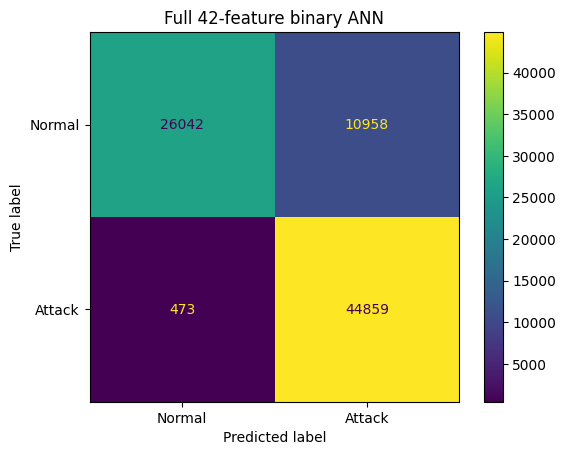

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

full_confusion_matrix = confusion_matrix(
    y_test,
    full_test_prediction,
    labels=[0, 1],
)

display(
    pd.DataFrame(
        full_confusion_matrix,
        index=[
            "Actual Normal",
            "Actual Attack",
        ],
        columns=[
            "Predicted Normal",
            "Predicted Attack",
        ],
    )
)

full_confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=full_confusion_matrix,
    display_labels=[
        "Normal",
        "Attack",
    ],
)

full_confusion_display.plot(
    values_format="d",
)

plt.title("Full 42-feature binary ANN")
plt.show()

# **Deep Learning Approach for Intelligent Intrusion Detection System**

In [ ]:
random.seed(42)
np.random.seed(42)
tf.keras.utils.set_random_seed(42)

In [ ]:
training_data = training_data.loc[
    :,
    ~training_data.columns.astype(str).str.startswith("Unnamed:")
].copy()

testing_data = testing_data.loc[
    :,
    ~testing_data.columns.astype(str).str.startswith("Unnamed:")
].copy()

training_data.columns = [
    str(column)
    .strip()
    .lower()
    .replace(" ", "_")
    .replace("-", "_")
    for column in training_data.columns
]

testing_data.columns = [
    str(column)
    .strip()
    .lower()
    .replace(" ", "_")
    .replace("-", "_")
    for column in testing_data.columns
]

print("Training columns:", training_data.columns.tolist())

Training columns: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


In [ ]:
required_columns = [
    "id",
    "proto",
    "service",
    "state",
    "attack_cat",
    "label",
]

for column in required_columns:
    if column not in training_data.columns:
        raise ValueError(
            f"Missing training column: {column}"
        )

    if column not in testing_data.columns:
        raise ValueError(
            f"Missing testing column: {column}"
        )

assert len(training_data) == 175_341, (
    f"Expected 175,341 training records, "
    f"found {len(training_data):,}."
)

assert len(testing_data) == 82_332, (
    f"Expected 82,332 testing records, "
    f"found {len(testing_data):,}."
)

print("Official file sizes are correct.")

Official file sizes are correct.


In [ ]:
feature_columns = [
    column
    for column in training_data.columns
    if column not in [
        "id",
        "attack_cat",
        "label",
    ]
]

categorical_columns = [
    "proto",
    "service",
    "state",
]

numerical_columns = [
    column
    for column in feature_columns
    if column not in categorical_columns
]

print("Input features:", len(feature_columns))
print("Categorical features:", categorical_columns)
print("Numerical features:", len(numerical_columns))


Input features: 42
Categorical features: ['proto', 'service', 'state']
Numerical features: 39


In [ ]:
for column in categorical_columns:
    training_data[column] = (
        training_data[column]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    testing_data[column] = (
        testing_data[column]
        .astype(str)
        .str.strip()
        .str.lower()
    )

for column in numerical_columns:
    training_data[column] = pd.to_numeric(
        training_data[column],
        errors="raise",
    )

    testing_data[column] = pd.to_numeric(
        testing_data[column],
        errors="raise",
    )

training_data["label"] = pd.to_numeric(
    training_data["label"],
    errors="raise",
).astype("int8")

testing_data["label"] = pd.to_numeric(
    testing_data["label"],
    errors="raise",
).astype("int8")

print(
    "Training missing values:",
    training_data[feature_columns + ["label"]]
    .isna()
    .sum()
    .sum(),
)

print(
    "Testing missing values:",
    testing_data[feature_columns + ["label"]]
    .isna()
    .sum()
    .sum(),
)



Training missing values: 0
Testing missing values: 0


In [ ]:
binary_distribution = pd.DataFrame(
    {
        "Dataset": [
            "Official training",
            "Official testing",
        ],
        "Normal": [
            int(
                np.sum(
                    training_data["label"] == 0
                )
            ),
            int(
                np.sum(
                    testing_data["label"] == 0
                )
            ),
        ],
        "Attack": [
            int(
                np.sum(
                    training_data["label"] == 1
                )
            ),
            int(
                np.sum(
                    testing_data["label"] == 1
                )
            ),
        ],
    }
)

binary_distribution["Total"] = (
    binary_distribution["Normal"]
    + binary_distribution["Attack"]
)

display(binary_distribution)

,Dataset,Normal,Attack,Total
0,Official training,56000,119341,175341
1,Official testing,37000,45332,82332


In [ ]:
train_indices, validation_indices = train_test_split(
    np.arange(len(training_data)),
    test_size=0.20,
    random_state=42,
    shuffle=True,
    stratify=training_data["label"],
)

train_data = (
    training_data
    .iloc[train_indices]
    .reset_index(drop=True)
)

validation_data = (
    training_data
    .iloc[validation_indices]
    .reset_index(drop=True)
)

test_data = testing_data.reset_index(
    drop=True
)

print("Training records:", len(train_data))
print("Validation records:", len(validation_data))
print("Testing records:", len(test_data))

Training records: 140272
Validation records: 35069
Testing records: 82332


In [ ]:
split_distribution = pd.DataFrame(
    {
        "Split": [
            "Training",
            "Validation",
            "Testing",
        ],
        "Normal": [
            int(np.sum(train_data["label"] == 0)),
            int(np.sum(validation_data["label"] == 0)),
            int(np.sum(test_data["label"] == 0)),
        ],
        "Attack": [
            int(np.sum(train_data["label"] == 1)),
            int(np.sum(validation_data["label"] == 1)),
            int(np.sum(test_data["label"] == 1)),
        ],
    }
)

split_distribution["Total"] = (
    split_distribution["Normal"]
    + split_distribution["Attack"]
)

split_distribution["Attack proportion"] = (
    split_distribution["Attack"]
    / split_distribution["Total"]
)

display(
    split_distribution.style.format(
        {
            "Attack proportion": "{:.6f}",
        }
    )
)

,Split,Normal,Attack,Total,Attack proportion
0,Training,44800,95472,140272,0.680621
1,Validation,11200,23869,35069,0.680630
2,Testing,37000,45332,82332,0.550600


In [ ]:
y_train = train_data[
    "label"
].to_numpy(
    dtype="float32"
)

y_validation = validation_data[
    "label"
].to_numpy(
    dtype="float32"
)

y_test = test_data[
    "label"
].to_numpy(
    dtype="int8"
)

print("Training target:", y_train.shape)
print("Validation target:", y_validation.shape)
print("Testing target:", y_test.shape)

print("0 = Normal")
print("1 = Attack")

Training target: (140272,)
Validation target: (35069,)
Testing target: (82332,)
0 = Normal
1 = Attack


In [ ]:
categorical_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,
    dtype=np.float32,
)

train_categorical = categorical_encoder.fit_transform(
    train_data[
        categorical_columns
    ]
)

validation_categorical = categorical_encoder.transform(
    validation_data[
        categorical_columns
    ]
)

test_categorical = categorical_encoder.transform(
    test_data[
        categorical_columns
    ]
)

for column, categories in zip(
    categorical_columns,
    categorical_encoder.categories_,
):
    print(
        column,
        "categories:",
        len(categories),
    )

    print(categories)
    print()

proto categories: 133
['3pc' 'a/n' 'aes-sp3-d' 'any' 'argus' 'aris' 'arp' 'ax.25' 'bbn-rcc'
 'bna' 'br-sat-mon' 'cbt' 'cftp' 'chaos' 'compaq-peer' 'cphb' 'cpnx'
 'crtp' 'crudp' 'dcn' 'ddp' 'ddx' 'dgp' 'egp' 'eigrp' 'emcon' 'encap'
 'etherip' 'fc' 'fire' 'ggp' 'gmtp' 'gre' 'hmp' 'i-nlsp' 'iatp' 'ib'
 'icmp' 'idpr' 'idpr-cmtp' 'idrp' 'ifmp' 'igmp' 'igp' 'il' 'ip' 'ipcomp'
 'ipcv' 'ipip' 'iplt' 'ipnip' 'ippc' 'ipv6' 'ipv6-frag' 'ipv6-no'
 'ipv6-opts' 'ipv6-route' 'ipx-n-ip' 'irtp' 'isis' 'iso-ip' 'iso-tp4'
 'kryptolan' 'l2tp' 'larp' 'leaf-1' 'leaf-2' 'merit-inp' 'mfe-nsp' 'mhrp'
 'micp' 'mobile' 'mtp' 'mux' 'narp' 'netblt' 'nsfnet-igp' 'nvp' 'ospf'
 'pgm' 'pim' 'pipe' 'pnni' 'pri-enc' 'prm' 'ptp' 'pup' 'pvp' 'qnx' 'rdp'
 'rsvp' 'rtp' 'rvd' 'sat-expak' 'sat-mon' 'sccopmce' 'scps' 'sctp' 'sdrp'
 'secure-vmtp' 'sep' 'skip' 'sm' 'smp' 'snp' 'sprite-rpc' 'sps' 'srp'
 'st2' 'stp' 'sun-nd' 'swipe' 'tcf' 'tcp' 'tlsp' 'tp++' 'trunk-1'
 'trunk-2' 'ttp' 'udp' 'unas' 'uti' 'vines' 'visa' 'vmtp' 'vrrp

In [ ]:
train_features = train_data[
    feature_columns
].copy()

validation_features = validation_data[
    feature_columns
].copy()

test_features = test_data[
    feature_columns
].copy()

train_features[
    categorical_columns
] = train_categorical

validation_features[
    categorical_columns
] = validation_categorical

test_features[
    categorical_columns
] = test_categorical

X_train_unscaled = train_features.to_numpy(
    dtype="float32"
)

X_validation_unscaled = validation_features.to_numpy(
    dtype="float32"
)

X_test_unscaled = test_features.to_numpy(
    dtype="float32"
)

print("Training matrix:", X_train_unscaled.shape)
print("Validation matrix:", X_validation_unscaled.shape)
print("Testing matrix:", X_test_unscaled.shape)



Training matrix: (140272, 42)
Validation matrix: (35069, 42)
Testing matrix: (82332, 42)


In [ ]:

from sklearn.preprocessing import normalize
X_train = normalize(
    X_train_unscaled,
    norm="l2",
    axis=1,
).astype("float32")

X_validation = normalize(
    X_validation_unscaled,
    norm="l2",
    axis=1,
).astype("float32")

X_test = normalize(
    X_test_unscaled,
    norm="l2",
    axis=1,
).astype("float32")

print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)

print(
    "First five training row norms:",
    np.linalg.norm(
        X_train[:5],
        axis=1,
    ),
)



X_train: (140272, 42)
X_validation: (35069, 42)
X_test: (82332, 42)
First five training row norms: [0.99999994 1.         1.         1.0000001  1.        ]


In [ ]:
model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(
            shape=(42,),
            name="unsw_nb15_features",
        ),

        tf.keras.layers.Dense(
            1024,
            activation="relu",
            kernel_initializer=tf.keras.initializers.GlorotUniform(
                seed=42
            ),
            name="dense_1024",
        ),

        tf.keras.layers.BatchNormalization(
            momentum=0.99,
            epsilon=0.001,
            name="batch_norm_1024",
        ),

        tf.keras.layers.Dropout(
            rate=0.01,
            seed=42,
            name="dropout_1024",
        ),

        tf.keras.layers.Dense(
            768,
            activation="relu",
            kernel_initializer=tf.keras.initializers.GlorotUniform(
                seed=43
            ),
            name="dense_768",
        ),

        tf.keras.layers.BatchNormalization(
            momentum=0.99,
            epsilon=0.001,
            name="batch_norm_768",
        ),

        tf.keras.layers.Dropout(
            rate=0.01,
            seed=43,
            name="dropout_768",
        ),

        tf.keras.layers.Dense(
            512,
            activation="relu",
            kernel_initializer=tf.keras.initializers.GlorotUniform(
                seed=44
            ),
            name="dense_512",
        ),

        tf.keras.layers.BatchNormalization(
            momentum=0.99,
            epsilon=0.001,
            name="batch_norm_512",
        ),

        tf.keras.layers.Dropout(
            rate=0.01,
            seed=44,
            name="dropout_512",
        ),

        tf.keras.layers.Dense(
            256,
            activation="relu",
            kernel_initializer=tf.keras.initializers.GlorotUniform(
                seed=45
            ),
            name="dense_256",
        ),

        tf.keras.layers.BatchNormalization(
            momentum=0.99,
            epsilon=0.001,
            name="batch_norm_256",
        ),

        tf.keras.layers.Dropout(
            rate=0.01,
            seed=45,
            name="dropout_256",
        ),

        tf.keras.layers.Dense(
            128,
            activation="relu",
            kernel_initializer=tf.keras.initializers.GlorotUniform(
                seed=46
            ),
            name="dense_128",
        ),

        tf.keras.layers.BatchNormalization(
            momentum=0.99,
            epsilon=0.001,
            name="batch_norm_128",
        ),

        tf.keras.layers.Dropout(
            rate=0.01,
            seed=46,
            name="dropout_128",
        ),

        tf.keras.layers.Dense(
            1,
            activation="sigmoid",
            kernel_initializer=tf.keras.initializers.GlorotUniform(
                seed=47
            ),
            name="binary_output",
        ),
    ],
    name="unsw_nb15_binary_dnn_5_layers",
)

model.summary()

Model: "unsw_nb15_binary_dnn_5_layers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1024 (Dense)              │ (None, 1024)           │        44,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1024                 │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1024 (Dropout)          │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_768 (Dense)               │ (None, 768)            │       787,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_768                  │ (None, 768)            │         3,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_768 (Dropout)           │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_512 (Dense)               │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_512                  │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_512 (Dropout)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_256                  │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_256 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_128                  │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_128 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ binary_output (Dense)           │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,400,065 (5.34 MB)

 Trainable params: 1,394,689 (5.32 MB)

 Non-trainable params: 5,376 (21.00 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.1,
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-7,
        amsgrad=False,
    ),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy",
            threshold=0.5,
        ),
        tf.keras.metrics.Precision(
            name="precision",
            thresholds=0.5,
        ),
        tf.keras.metrics.Recall(
            name="recall",
            thresholds=0.5,
        ),
        tf.keras.metrics.AUC(
            name="auc",
        ),
    ],
)

In [ ]:
best_model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="best_unsw_nb15_binary_dnn_5_layers.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1,
)

In [ ]:

history = model.fit(
    X_train,
    y_train,
    validation_data=(
        X_validation,
        y_validation,
    ),
    epochs=500,
    batch_size=64,
    shuffle=True,
    callbacks=[
        best_model_checkpoint,
    ],
    verbose=2,
)


Epoch 1/500

Epoch 1: val_accuracy improved from None to 0.74365, saving model to best_unsw_nb15_binary_dnn_5_layers.keras

Epoch 1: finished saving model to best_unsw_nb15_binary_dnn_5_layers.keras
2192/2192 - 47s - 22ms/step - accuracy: 0.7580 - auc: 0.8403 - loss: 0.4324 - precision: 0.8037 - recall: 0.8528 - val_accuracy: 0.7436 - val_auc: 0.8253 - val_loss: 0.7951 - val_precision: 0.9592 - val_recall: 0.6511
Epoch 2/500

Epoch 2: val_accuracy improved from 0.74365 to 0.75520, saving model to best_unsw_nb15_binary_dnn_5_layers.keras

Epoch 2: finished saving model to best_unsw_nb15_binary_dnn_5_layers.keras
2192/2192 - 7s - 3ms/step - accuracy: 0.7573 - auc: 0.8430 - loss: 0.4182 - precision: 0.8008 - recall: 0.8565 - val_accuracy: 0.7552 - val_auc: 0.8647 - val_loss: 21968.0547 - val_precision: 0.8719 - val_recall: 0.7506
Epoch 3/500

Epoch 3: val_accuracy did not improve from 0.75520
2192/2192 - 7s - 3ms/step - accuracy: 0.7714 - auc: 0.8525 - loss: 0.4161 - precision: 0.8104 - r

In [ ]:
test_probability = model.predict(
    X_test,
    batch_size=1024,
    verbose=1,
).reshape(-1)

test_prediction = (
    test_probability >= 0.5
).astype("int8")

print(
    "Probability range:",
    test_probability.min(),
    test_probability.max(),
)

print(
    "Predicted Normal:",
    int(np.sum(test_prediction == 0)),
)

print(
    "Predicted Attack:",
    int(np.sum(test_prediction == 1)),
)

81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step
Probability range: 0.0 1.0
Predicted Normal: 31835
Predicted Attack: 50497


In [ ]:
test_matrix = confusion_matrix(
    y_test,
    test_prediction,
    labels=[0, 1],
)

true_normal, normal_as_attack, attack_as_normal, true_attack = (
    test_matrix.ravel()
)

test_accuracy = accuracy_score(
    y_test,
    test_prediction,
)

test_precision = precision_score(
    y_test,
    test_prediction,
    pos_label=1,
    zero_division=0,
)

test_recall = recall_score(
    y_test,
    test_prediction,
    pos_label=1,
    zero_division=0,
)

test_f1 = f1_score(
    y_test,
    test_prediction,
    pos_label=1,
    zero_division=0,
)

test_auc = roc_auc_score(
    y_test,
    test_probability,
)

false_positive_rate = (
    normal_as_attack
    / (
        true_normal
        + normal_as_attack
    )
)

false_negative_rate = (
    attack_as_normal
    / (
        true_attack
        + attack_as_normal
    )
)

test_results = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score",
            "ROC AUC",
            "False-positive rate",
            "False-negative rate",
        ],
        "Reproduction": [
            test_accuracy,
            test_precision,
            test_recall,
            test_f1,
            test_auc,
            false_positive_rate,
            false_negative_rate,
        ],
    }
)

display(
    test_results.style.format(
        {
            "Reproduction": "{:.6f}",
        }
    )
)

print("Correct Normal:", true_normal)
print("Normal predicted Attack:", normal_as_attack)
print("Attack predicted Normal:", attack_as_normal)
print("Correct Attack:", true_attack)

,Metric,Reproduction
0,Accuracy,0.751482
1,Precision,0.746262
2,Recall,0.831289
3,F1-score,0.786484
4,ROC AUC,0.824873
5,False-positive rate,0.346297
6,False-negative rate,0.168711


Correct Normal: 24187
Normal predicted Attack: 12813
Attack predicted Normal: 7648
Correct Attack: 37684


,Predicted Normal,Predicted Attack
Actual Normal,24187,12813
Actual Attack,7648,37684


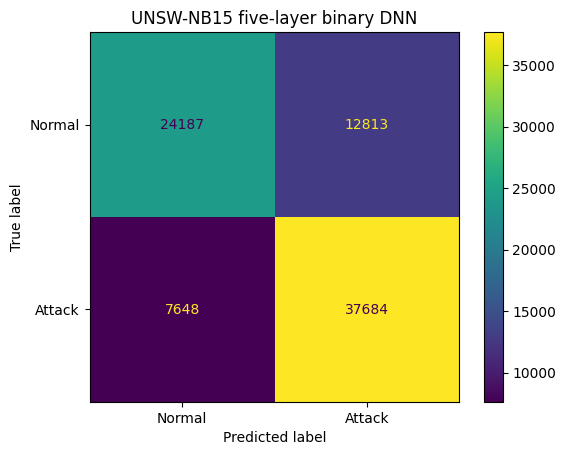

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
confusion_table = pd.DataFrame(
    test_matrix,
    index=[
        "Actual Normal",
        "Actual Attack",
    ],
    columns=[
        "Predicted Normal",
        "Predicted Attack",
    ],
)

display(confusion_table)

confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=test_matrix,
    display_labels=[
        "Normal",
        "Attack",
    ],
)

confusion_display.plot(
    values_format="d",
)

plt.title(
    "UNSW-NB15 five-layer binary DNN"
)
plt.show()

In [ ]:
model.save("/content/drive/MyDrive/Models_Table_7/DNN_Vinayakumar_unsw-nb15.keras")

# **An effective intrusion detection approachusing SVM with naïve Bayes feature embedding**

In [ ]:
random.seed(42)
np.random.seed(42)

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DATASETS/UNSW-NB15/UNSW_NB15_training-set.csv")
print("Raw shape:", data.shape)

display(data.head())

Raw shape: (175341, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [ ]:
data = data.loc[
    :,
    ~data.columns.astype(str).str.startswith("Unnamed:")
].copy()

data.columns = [
    str(column)
    .strip()
    .lower()
    .replace(" ", "_")
    .replace("-", "_")
    for column in data.columns
]

print("Prepared shape:", data.shape)
print(data.columns.tolist())

Prepared shape: (175341, 45)
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


In [ ]:
feature_columns = [
    column
    for column in data.columns
    if column not in [
        "id",
        "attack_cat",
        "label",
    ]
]

categorical_columns = [
    "proto",
    "service",
    "state",
]

numerical_columns = [
    column
    for column in feature_columns
    if column not in categorical_columns
]

print("Predictive features:", len(feature_columns))
print("Categorical features:", categorical_columns)
print("Numerical features:", len(numerical_columns))


Predictive features: 42
Categorical features: ['proto', 'service', 'state']
Numerical features: 39


In [ ]:
for column in categorical_columns:
    data[column] = (
        data[column]
        .astype(str)
        .str.strip()
        .str.lower()
    )

for column in numerical_columns:
    data[column] = pd.to_numeric(
        data[column],
        errors="raise",
    )

data["label"] = pd.to_numeric(
    data["label"],
    errors="raise",
).astype("int8")

missing_values = (
    data[feature_columns + ["label"]]
    .isna()
    .sum()
    .sum()
)

infinite_values = np.isinf(
    data[numerical_columns].to_numpy(
        dtype="float64"
    )
).sum()

print("Missing values:", missing_values)
print("Infinite numerical values:", infinite_values)

assert missing_values == 0
assert infinite_values == 0
assert set(data["label"].unique()) == {0, 1}

Missing values: 0
Infinite numerical values: 0


In [ ]:
original_distribution = pd.DataFrame(
    {
        "Class": [
            "Normal",
            "Attack",
        ],
        "Label": [
            0,
            1,
        ],
        "Count": [
            int(np.sum(data["label"] == 0)),
            int(np.sum(data["label"] == 1)),
        ],
    }
)

display(original_distribution)



,Class,Label,Count
0,Normal,0,56000
1,Attack,1,119341


In [ ]:
normal_data = data.loc[
    data["label"] == 0
].copy()

attack_data = data.loc[
    data["label"] == 1
].sample(
    n=62_000,
    replace=False,
    random_state=42,
)

sampled_data = pd.concat(
    [
        normal_data,
        attack_data,
    ],
    axis=0,
    ignore_index=True,
)

sampled_data = sampled_data.sample(
    frac=1.0,
    random_state=42,
).reset_index(
    drop=True
)

print("Extracted records:", len(sampled_data))

print(
    "Normal:",
    int(np.sum(sampled_data["label"] == 0)),
)

print(
    "Attack:",
    int(np.sum(sampled_data["label"] == 1)),
)


Extracted records: 118000
Normal: 56000
Attack: 62000


In [ ]:
extracted_distribution = pd.DataFrame(
    {
        "Class": [
            "Normal",
            "Attack",
        ],
        "Count": [
            int(np.sum(sampled_data["label"] == 0)),
            int(np.sum(sampled_data["label"] == 1)),
        ],
    }
)

extracted_distribution["Percentage"] = (
    extracted_distribution["Count"]
    / len(sampled_data)
    * 100
)

display(
    extracted_distribution.style.format(
        {
            "Percentage": "{:.3f}%",
        }
    )
)

,Class,Count,Percentage
0,Normal,56000,47.458%
1,Attack,62000,52.542%


In [ ]:
categorical_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,
    dtype=np.float64,
)

encoded_categorical = categorical_encoder.fit_transform(
    sampled_data[
        categorical_columns
    ]
)

encoded_features = sampled_data[
    feature_columns
].copy()

encoded_features[
    categorical_columns
] = encoded_categorical

for column, categories in zip(
    categorical_columns,
    categorical_encoder.categories_,
):
    print(
        column,
        "number of categories:",
        len(categories),
    )

    print(categories)
    print()

proto number of categories: 133
['3pc' 'a/n' 'aes-sp3-d' 'any' 'argus' 'aris' 'arp' 'ax.25' 'bbn-rcc'
 'bna' 'br-sat-mon' 'cbt' 'cftp' 'chaos' 'compaq-peer' 'cphb' 'cpnx'
 'crtp' 'crudp' 'dcn' 'ddp' 'ddx' 'dgp' 'egp' 'eigrp' 'emcon' 'encap'
 'etherip' 'fc' 'fire' 'ggp' 'gmtp' 'gre' 'hmp' 'i-nlsp' 'iatp' 'ib'
 'icmp' 'idpr' 'idpr-cmtp' 'idrp' 'ifmp' 'igmp' 'igp' 'il' 'ip' 'ipcomp'
 'ipcv' 'ipip' 'iplt' 'ipnip' 'ippc' 'ipv6' 'ipv6-frag' 'ipv6-no'
 'ipv6-opts' 'ipv6-route' 'ipx-n-ip' 'irtp' 'isis' 'iso-ip' 'iso-tp4'
 'kryptolan' 'l2tp' 'larp' 'leaf-1' 'leaf-2' 'merit-inp' 'mfe-nsp' 'mhrp'
 'micp' 'mobile' 'mtp' 'mux' 'narp' 'netblt' 'nsfnet-igp' 'nvp' 'ospf'
 'pgm' 'pim' 'pipe' 'pnni' 'pri-enc' 'prm' 'ptp' 'pup' 'pvp' 'qnx' 'rdp'
 'rsvp' 'rtp' 'rvd' 'sat-expak' 'sat-mon' 'sccopmce' 'scps' 'sctp' 'sdrp'
 'secure-vmtp' 'sep' 'skip' 'sm' 'smp' 'snp' 'sprite-rpc' 'sps' 'srp'
 'st2' 'stp' 'sun-nd' 'swipe' 'tcf' 'tcp' 'tlsp' 'tp++' 'trunk-1'
 'trunk-2' 'ttp' 'udp' 'unas' 'uti' 'vines' 'visa' 'v

In [ ]:
feature_scaler = MinMaxScaler(
    feature_range=(0, 1)
)

X_all = feature_scaler.fit_transform(
    encoded_features.to_numpy(
        dtype="float64"
    )
)

y_all = sampled_data[
    "label"
].to_numpy(
    dtype="int8"
)

print("Feature matrix:", X_all.shape)
print("Target vector:", y_all.shape)
print("Minimum feature value:", X_all.min())
print("Maximum feature value:", X_all.max())



Feature matrix: (118000, 42)
Target vector: (118000,)
Minimum feature value: 0.0
Maximum feature value: 1.0000000000000002


In [ ]:
cross_validation = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42,
)

fold_results = []

out_of_fold_prediction = np.empty(
    len(y_all),
    dtype="int8",
)

out_of_fold_decision_score = np.empty(
    len(y_all),
    dtype="float64",
)

print(cross_validation)

StratifiedKFold(n_splits=10, random_state=42, shuffle=True)


In [ ]:
from scipy.ndimage import gaussian_filter1d
from sklearn.svm import SVC

for fold_number, (
    cross_validation_train_indices,
    cross_validation_test_indices,
) in enumerate(
    cross_validation.split(
        X_all,
        y_all,
    ),
    start=1,
):
    fold_start = time.perf_counter()

    s1_indices, s2_indices = train_test_split(
        cross_validation_train_indices,
        test_size=0.50,
        random_state=42 + fold_number,
        shuffle=True,
        stratify=y_all[
            cross_validation_train_indices
        ],
    )

    X_s1 = X_all[
        s1_indices
    ]

    y_s1 = y_all[
        s1_indices
    ]

    X_s2 = X_all[
        s2_indices
    ]

    y_s2 = y_all[
        s2_indices
    ]

    X_fold_test = X_all[
        cross_validation_test_indices
    ]

    y_fold_test = y_all[
        cross_validation_test_indices
    ]

    normal_prior = np.mean(
        y_s1 == 0
    )

    attack_prior = np.mean(
        y_s1 == 1
    )

    log_prior_ratio = np.log(
        normal_prior / attack_prior
    )

    grid_edges = np.linspace(
        -0.10,
        1.10,
        2049,
        dtype="float64",
    )

    grid_centres = (
        grid_edges[:-1]
        + grid_edges[1:]
    ) / 2

    grid_width = (
        grid_edges[1]
        - grid_edges[0]
    )

    embedded_s2 = np.empty(
        X_s2.shape,
        dtype="float64",
    )

    embedded_test = np.empty(
        X_fold_test.shape,
        dtype="float64",
    )

    for feature_index in range(
        X_all.shape[1]
    ):
        normal_values = X_s1[
            y_s1 == 0,
            feature_index,
        ]

        attack_values = X_s1[
            y_s1 == 1,
            feature_index,
        ]

        normal_standard_deviation = np.std(
            normal_values,
            ddof=1,
        )

        normal_interquartile_range = (
            np.percentile(
                normal_values,
                75,
            )
            - np.percentile(
                normal_values,
                25,
            )
        )

        normal_scales = []

        if (
            np.isfinite(
                normal_standard_deviation
            )
            and normal_standard_deviation > 0
        ):
            normal_scales.append(
                normal_standard_deviation
            )

        if (
            np.isfinite(
                normal_interquartile_range
            )
            and normal_interquartile_range > 0
        ):
            normal_scales.append(
                normal_interquartile_range
                / 1.34
            )

        if len(normal_scales) > 0:
            normal_scale = min(
                normal_scales
            )
        else:
            normal_scale = grid_width * 2

        normal_bandwidth = max(
            0.9
            * normal_scale
            * len(normal_values) ** (-0.2),
            grid_width * 1.5,
        )

        attack_standard_deviation = np.std(
            attack_values,
            ddof=1,
        )

        attack_interquartile_range = (
            np.percentile(
                attack_values,
                75,
            )
            - np.percentile(
                attack_values,
                25,
            )
        )

        attack_scales = []

        if (
            np.isfinite(
                attack_standard_deviation
            )
            and attack_standard_deviation > 0
        ):
            attack_scales.append(
                attack_standard_deviation
            )

        if (
            np.isfinite(
                attack_interquartile_range
            )
            and attack_interquartile_range > 0
        ):
            attack_scales.append(
                attack_interquartile_range
                / 1.34
            )

        if len(attack_scales) > 0:
            attack_scale = min(
                attack_scales
            )
        else:
            attack_scale = grid_width * 2

        attack_bandwidth = max(
            0.9
            * attack_scale
            * len(attack_values) ** (-0.2),
            grid_width * 1.5,
        )

        normal_histogram, _ = np.histogram(
            normal_values,
            bins=grid_edges,
        )

        attack_histogram, _ = np.histogram(
            attack_values,
            bins=grid_edges,
        )

        normal_density = gaussian_filter1d(
            normal_histogram.astype(
                "float64"
            ),
            sigma=(
                normal_bandwidth
                / grid_width
            ),
            mode="constant",
            cval=0.0,
        )

        attack_density = gaussian_filter1d(
            attack_histogram.astype(
                "float64"
            ),
            sigma=(
                attack_bandwidth
                / grid_width
            ),
            mode="constant",
            cval=0.0,
        )

        normal_density = normal_density / (
            normal_density.sum()
            * grid_width
        )

        attack_density = attack_density / (
            attack_density.sum()
            * grid_width
        )

        normal_density = np.maximum(
            normal_density,
            1e-12,
        )

        attack_density = np.maximum(
            attack_density,
            1e-12,
        )

        s2_normal_density = np.interp(
            X_s2[
                :,
                feature_index,
            ],
            grid_centres,
            normal_density,
            left=1e-12,
            right=1e-12,
        )

        s2_attack_density = np.interp(
            X_s2[
                :,
                feature_index,
            ],
            grid_centres,
            attack_density,
            left=1e-12,
            right=1e-12,
        )

        test_normal_density = np.interp(
            X_fold_test[
                :,
                feature_index,
            ],
            grid_centres,
            normal_density,
            left=1e-12,
            right=1e-12,
        )

        test_attack_density = np.interp(
            X_fold_test[
                :,
                feature_index,
            ],
            grid_centres,
            attack_density,
            left=1e-12,
            right=1e-12,
        )

        embedded_s2[
            :,
            feature_index,
        ] = (
            log_prior_ratio
            + np.log(
                s2_normal_density
            )
            - np.log(
                s2_attack_density
            )
        )

        embedded_test[
            :,
            feature_index,
        ] = (
            log_prior_ratio
            + np.log(
                test_normal_density
            )
            - np.log(
                test_attack_density
            )
        )

    embedded_scaler = StandardScaler()

    embedded_s2 = embedded_scaler.fit_transform(
        embedded_s2
    )

    embedded_test = embedded_scaler.transform(
        embedded_test
    )

    svm_model = SVC(
        C=1.0,
        kernel="rbf",
        gamma="auto",
        shrinking=True,
        probability=False,
        cache_size=4096,
        class_weight=None,
        max_iter=-1,
        decision_function_shape="ovr",
    )

    svm_model.fit(
        embedded_s2,
        y_s2,
    )

    fold_prediction = svm_model.predict(
        embedded_test
    ).astype(
        "int8"
    )

    fold_decision_score = (
        svm_model.decision_function(
            embedded_test
        )
    )

    out_of_fold_prediction[
        cross_validation_test_indices
    ] = fold_prediction

    out_of_fold_decision_score[
        cross_validation_test_indices
    ] = fold_decision_score

    fold_matrix = confusion_matrix(
        y_fold_test,
        fold_prediction,
        labels=[0, 1],
    )

    true_normal, false_alarm, missed_attack, detected_attack = (
        fold_matrix.ravel()
    )

    fold_accuracy = accuracy_score(
        y_fold_test,
        fold_prediction,
    )

    fold_detection_rate = (
        detected_attack
        / (
            detected_attack
            + missed_attack
        )
    )

    fold_false_alarm_rate = (
        false_alarm
        / (
            false_alarm
            + true_normal
        )
    )

    fold_precision = precision_score(
        y_fold_test,
        fold_prediction,
        pos_label=1,
        zero_division=0,
    )

    fold_f1 = f1_score(
        y_fold_test,
        fold_prediction,
        pos_label=1,
        zero_division=0,
    )

    fold_auc = roc_auc_score(
        y_fold_test,
        fold_decision_score,
    )

    fold_seconds = (
        time.perf_counter()
        - fold_start
    )

    fold_results.append(
        {
            "Fold": fold_number,
            "S1 records": len(s1_indices),
            "S2 records": len(s2_indices),
            "Test records": len(
                cross_validation_test_indices
            ),
            "Accuracy": fold_accuracy,
            "Detection rate": fold_detection_rate,
            "False alarm rate": fold_false_alarm_rate,
            "Precision": fold_precision,
            "F1-score": fold_f1,
            "ROC AUC": fold_auc,
            "Seconds": fold_seconds,
        }
    )

    print(
        f"Fold {fold_number:02d} | "
        f"Accuracy={fold_accuracy:.6f} | "
        f"DR={fold_detection_rate:.6f} | "
        f"FAR={fold_false_alarm_rate:.6f} | "
        f"Time={fold_seconds:.2f}s"
    )



Fold 01 | Accuracy=0.924576 | DR=0.973226 | FAR=0.129286 | Time=82.89s
Fold 02 | Accuracy=0.918390 | DR=0.967581 | FAR=0.136071 | Time=72.68s
Fold 03 | Accuracy=0.920932 | DR=0.971452 | FAR=0.135000 | Time=72.76s
Fold 04 | Accuracy=0.917966 | DR=0.972419 | FAR=0.142321 | Time=69.34s
Fold 05 | Accuracy=0.920847 | DR=0.969677 | FAR=0.133214 | Time=69.97s
Fold 06 | Accuracy=0.924237 | DR=0.970323 | FAR=0.126786 | Time=73.45s
Fold 07 | Accuracy=0.916949 | DR=0.969032 | FAR=0.140714 | Time=72.94s
Fold 08 | Accuracy=0.920085 | DR=0.978871 | FAR=0.145000 | Time=70.35s
Fold 09 | Accuracy=0.922712 | DR=0.969677 | FAR=0.129286 | Time=70.01s
Fold 10 | Accuracy=0.920169 | DR=0.965323 | FAR=0.129821 | Time=69.45s


In [ ]:
fold_results_table = pd.DataFrame(
    fold_results
)

display(
    fold_results_table.style.format(
        {
            "Accuracy": "{:.6f}",
            "Detection rate": "{:.6f}",
            "False alarm rate": "{:.6f}",
            "Precision": "{:.6f}",
            "F1-score": "{:.6f}",
            "ROC AUC": "{:.6f}",
            "Seconds": "{:.2f}",
        }
    )
)

,Fold,S1 records,S2 records,Test records,Accuracy,Detection rate,False alarm rate,Precision,F1-score,ROC AUC,Seconds
0,1,53100,53100,11800,0.924576,0.973226,0.129286,0.892868,0.931317,0.984500,82.89
1,2,53100,53100,11800,0.918390,0.967581,0.136071,0.887295,0.925700,0.982567,72.68
2,3,53100,53100,11800,0.920932,0.971452,0.135000,0.888479,0.928115,0.982716,72.76
3,4,53100,53100,11800,0.917966,0.972419,0.142321,0.883241,0.925687,0.983528,69.34
4,5,53100,53100,11800,0.920847,0.969677,0.133214,0.889612,0.927921,0.982298,69.97
5,6,53100,53100,11800,0.924237,0.970323,0.126786,0.894439,0.930837,0.984197,73.45
6,7,53100,53100,11800,0.916949,0.969032,0.140714,0.884049,0.924592,0.982248,72.94
7,8,53100,53100,11800,0.920085,0.978871,0.145000,0.881994,0.927911,0.982695,70.35
8,9,53100,53100,11800,0.922712,0.969677,0.129286,0.892518,0.929499,0.982682,70.01
9,10,53100,53100,11800,0.920169,0.965323,0.129821,0.891687,0.927045,0.981159,69.45


In [ ]:
accuracy_mean = (
    fold_results_table["Accuracy"]
    .mean()
)

accuracy_standard_error = (
    fold_results_table["Accuracy"]
    .std(ddof=1)
    / np.sqrt(10)
)

detection_rate_mean = (
    fold_results_table[
        "Detection rate"
    ].mean()
)

detection_rate_standard_error = (
    fold_results_table[
        "Detection rate"
    ].std(ddof=1)
    / np.sqrt(10)
)

false_alarm_rate_mean = (
    fold_results_table[
        "False alarm rate"
    ].mean()
)

false_alarm_rate_standard_error = (
    fold_results_table[
        "False alarm rate"
    ].std(ddof=1)
    / np.sqrt(10)
)

precision_mean = (
    fold_results_table[
        "Precision"
    ].mean()
)

f1_mean = (
    fold_results_table[
        "F1-score"
    ].mean()
)

auc_mean = (
    fold_results_table[
        "ROC AUC"
    ].mean()
)

cross_validation_summary = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Detection rate",
            "False alarm rate",
            "Precision",
            "F1-score",
            "ROC AUC",
        ],
        "Mean": [
            accuracy_mean,
            detection_rate_mean,
            false_alarm_rate_mean,
            precision_mean,
            f1_mean,
            auc_mean,
        ],
        "Standard error": [
            accuracy_standard_error,
            detection_rate_standard_error,
            false_alarm_rate_standard_error,
            np.nan,
            np.nan,
            np.nan,
        ],
    }
)

display(
    cross_validation_summary.style.format(
        {
            "Mean": "{:.6f}",
            "Standard error": "{:.6f}",
        },
        na_rep="Not calculated",
    )
)

,Metric,Mean,Standard error
0,Accuracy,0.920686,0.000811
1,Detection rate,0.970758,0.001156
2,False alarm rate,0.134750,0.001971
3,Precision,0.888618,Not calculated
4,F1-score,0.927862,Not calculated
5,ROC AUC,0.982859,Not calculated


,Predicted Normal,Predicted Attack
Actual Normal,48454,7546
Actual Attack,1813,60187


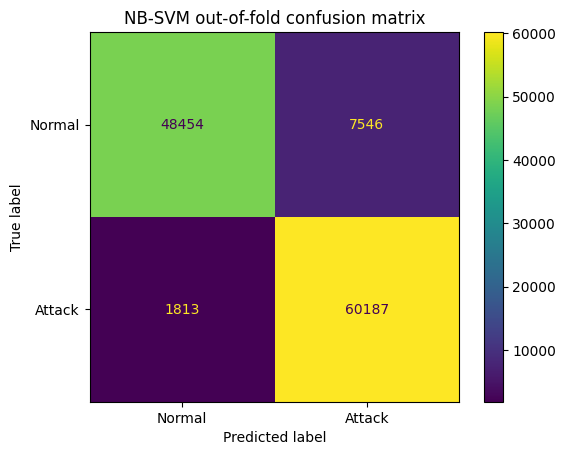

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
out_of_fold_matrix = confusion_matrix(
    y_all,
    out_of_fold_prediction,
    labels=[0, 1],
)

display(
    pd.DataFrame(
        out_of_fold_matrix,
        index=[
            "Actual Normal",
            "Actual Attack",
        ],
        columns=[
            "Predicted Normal",
            "Predicted Attack",
        ],
    )
)

out_of_fold_display = ConfusionMatrixDisplay(
    confusion_matrix=out_of_fold_matrix,
    display_labels=[
        "Normal",
        "Attack",
    ],
)

out_of_fold_display.plot(
    values_format="d",
)

plt.title(
    "NB-SVM out-of-fold confusion matrix"
)

plt.show()

In [ ]:
print(
    classification_report(
        y_all,
        out_of_fold_prediction,
        target_names=[
            "Normal",
            "Attack",
        ],
        digits=6,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

      Normal   0.963933  0.865250  0.911929     56000
      Attack   0.888592  0.970758  0.927860     62000

    accuracy                       0.920686    118000
   macro avg   0.926262  0.918004  0.919894    118000
weighted avg   0.924347  0.920686  0.920299    118000



# **Network anomaly detection and performance evaluation of Convolutional Neural Networks on UNSW-NB15 dataset**

In [ ]:
random.seed(42)
np.random.seed(42)
tf.keras.utils.set_random_seed(42)

In [ ]:
official_training_data = official_training_data.loc[
    :,
    ~official_training_data.columns.astype(str).str.startswith(
        "Unnamed:"
    ),
].copy()

official_testing_data = official_testing_data.loc[
    :,
    ~official_testing_data.columns.astype(str).str.startswith(
        "Unnamed:"
    ),
].copy()

official_training_data.columns = [
    str(column)
    .strip()
    .lower()
    .replace(" ", "_")
    .replace("-", "_")
    for column in official_training_data.columns
]

official_testing_data.columns = [
    str(column)
    .strip()
    .lower()
    .replace(" ", "_")
    .replace("-", "_")
    for column in official_testing_data.columns
]

print(
    "Training columns:",
    official_training_data.columns.tolist(),
)

Training columns: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


In [ ]:
required_columns = [
    "id",
    "proto",
    "service",
    "state",
    "attack_cat",
    "label",
]

for column in required_columns:
    if column not in official_training_data.columns:
        raise ValueError(
            f"Missing training column: {column}"
        )

    if column not in official_testing_data.columns:
        raise ValueError(
            f"Missing testing column: {column}"
        )



print("The official UNSW-NB15 files are valid.")

The official UNSW-NB15 files are valid.


In [ ]:
data = pd.concat(
    [
        official_training_data,
        official_testing_data,
    ],
    axis=0,
    ignore_index=True,
)

print("Combined dataset shape:", data.shape)

assert len(data) == 257_673

Combined dataset shape: (257673, 45)


In [ ]:
feature_columns = [
    column
    for column in data.columns
    if column not in [
        "id",
        "attack_cat",
        "label",
    ]
]

categorical_columns = [
    "proto",
    "service",
    "state",
]

numerical_columns = [
    column
    for column in feature_columns
    if column not in categorical_columns
]

print("Predictive features:", len(feature_columns))
print("Categorical features:", categorical_columns)
print("Numerical features:", len(numerical_columns))



Predictive features: 42
Categorical features: ['proto', 'service', 'state']
Numerical features: 39


In [ ]:
for column in categorical_columns:
    data[column] = (
        data[column]
        .astype(str)
        .str.strip()
        .str.lower()
    )

display(data[categorical_columns].head())

,proto,service,state
0,tcp,-,fin
1,tcp,-,fin
2,tcp,-,fin
3,tcp,ftp,fin
4,tcp,-,fin


In [ ]:
for column in numerical_columns:
    data[column] = pd.to_numeric(
        data[column],
        errors="coerce",
    )

data["label"] = pd.to_numeric(
    data["label"],
    errors="coerce",
)

print(
    "Rows containing missing values:",
    int(
        data[
            feature_columns + ["label"]
        ]
        .isna()
        .any(axis=1)
        .sum()
    ),
)

Rows containing missing values: 0


In [ ]:
data = data.replace(
    [np.inf, -np.inf],
    np.nan,
)

data = data.dropna(
    subset=feature_columns + ["label"],
).reset_index(drop=True)

data["label"] = data[
    "label"
].astype("int8")

print("Prepared dataset shape:", data.shape)
print("Exact duplicate rows:", data.duplicated().sum())

assert set(data["label"].unique()).issubset(
    {0, 1}
)

Prepared dataset shape: (257673, 45)
Exact duplicate rows: 0


In [ ]:
binary_distribution = pd.DataFrame(
    {
        "Class": [
            "Normal",
            "Attack",
        ],
        "Label": [
            0,
            1,
        ],
        "Count": [
            int(
                np.sum(
                    data["label"] == 0
                )
            ),
            int(
                np.sum(
                    data["label"] == 1
                )
            ),
        ],
    }
)

binary_distribution["Percentage"] = (
    binary_distribution["Count"]
    / len(data)
    * 100
)

display(
    binary_distribution.style.format(
        {
            "Percentage": "{:.3f}%",
        }
    )
)

,Class,Label,Count,Percentage
0,Normal,0,93000,36.092%
1,Attack,1,164673,63.908%


In [ ]:
development_data, test_data = train_test_split(
    data,
    test_size=0.30,
    random_state=42,
    shuffle=True,
    stratify=data["label"],
)

development_data = development_data.reset_index(
    drop=True
)

test_data = test_data.reset_index(
    drop=True
)

print(
    "Development records:",
    len(development_data),
)

print(
    "Test records:",
    len(test_data),
)

Development records: 180371
Test records: 77302


In [ ]:
train_data, validation_data = train_test_split(
    development_data,
    test_size=0.20,
    random_state=42,
    shuffle=True,
    stratify=development_data["label"],
)

train_data = train_data.reset_index(
    drop=True
)

validation_data = validation_data.reset_index(
    drop=True
)

print("Training records:", len(train_data))
print("Validation records:", len(validation_data))
print("Testing records:", len(test_data))

print(
    "Total records:",
    len(train_data)
    + len(validation_data)
    + len(test_data),
)

Training records: 144296
Validation records: 36075
Testing records: 77302
Total records: 257673


In [ ]:
split_distribution = pd.DataFrame(
    {
        "Split": [
            "Training",
            "Validation",
            "Testing",
        ],
        "Normal": [
            int(
                np.sum(
                    train_data["label"] == 0
                )
            ),
            int(
                np.sum(
                    validation_data["label"] == 0
                )
            ),
            int(
                np.sum(
                    test_data["label"] == 0
                )
            ),
        ],
        "Attack": [
            int(
                np.sum(
                    train_data["label"] == 1
                )
            ),
            int(
                np.sum(
                    validation_data["label"] == 1
                )
            ),
            int(
                np.sum(
                    test_data["label"] == 1
                )
            ),
        ],
    }
)

split_distribution["Total"] = (
    split_distribution["Normal"]
    + split_distribution["Attack"]
)

split_distribution["Attack proportion"] = (
    split_distribution["Attack"]
    / split_distribution["Total"]
)

display(
    split_distribution.style.format(
        {
            "Attack proportion": "{:.6f}",
        }
    )
)

,Split,Normal,Attack,Total,Attack proportion
0,Training,52080,92216,144296,0.639075
1,Validation,13020,23055,36075,0.639085
2,Testing,27900,49402,77302,0.639078


In [ ]:
y_train = train_data[
    "label"
].to_numpy(
    dtype="int8"
)

y_validation = validation_data[
    "label"
].to_numpy(
    dtype="int8"
)

y_test = test_data[
    "label"
].to_numpy(
    dtype="int8"
)

print("0 = Normal")
print("1 = Attack")

print("Training target:", y_train.shape)
print("Validation target:", y_validation.shape)
print("Testing target:", y_test.shape)

0 = Normal
1 = Attack
Training target: (144296,)
Validation target: (36075,)
Testing target: (77302,)


In [ ]:
categorical_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,
    dtype=np.float32,
)

train_categorical = categorical_encoder.fit_transform(
    train_data[
        categorical_columns
    ]
)

validation_categorical = categorical_encoder.transform(
    validation_data[
        categorical_columns
    ]
)

test_categorical = categorical_encoder.transform(
    test_data[
        categorical_columns
    ]
)

for column, categories in zip(
    categorical_columns,
    categorical_encoder.categories_,
):
    print(
        column,
        "categories:",
        len(categories),
    )

    print(categories)
    print()

proto categories: 132
['3pc' 'a/n' 'aes-sp3-d' 'any' 'argus' 'aris' 'arp' 'ax.25' 'bbn-rcc'
 'bna' 'br-sat-mon' 'cbt' 'cftp' 'chaos' 'compaq-peer' 'cphb' 'cpnx'
 'crtp' 'crudp' 'dcn' 'ddp' 'ddx' 'dgp' 'egp' 'eigrp' 'emcon' 'encap'
 'etherip' 'fc' 'fire' 'ggp' 'gmtp' 'gre' 'hmp' 'i-nlsp' 'iatp' 'ib'
 'icmp' 'idpr' 'idpr-cmtp' 'idrp' 'ifmp' 'igmp' 'igp' 'il' 'ip' 'ipcomp'
 'ipcv' 'ipip' 'iplt' 'ipnip' 'ippc' 'ipv6' 'ipv6-frag' 'ipv6-no'
 'ipv6-opts' 'ipv6-route' 'ipx-n-ip' 'irtp' 'isis' 'iso-ip' 'iso-tp4'
 'kryptolan' 'l2tp' 'larp' 'leaf-1' 'leaf-2' 'merit-inp' 'mfe-nsp' 'mhrp'
 'micp' 'mobile' 'mtp' 'mux' 'narp' 'netblt' 'nsfnet-igp' 'nvp' 'ospf'
 'pgm' 'pim' 'pipe' 'pnni' 'pri-enc' 'prm' 'ptp' 'pup' 'pvp' 'qnx' 'rdp'
 'rsvp' 'rvd' 'sat-expak' 'sat-mon' 'sccopmce' 'scps' 'sctp' 'sdrp'
 'secure-vmtp' 'sep' 'skip' 'sm' 'smp' 'snp' 'sprite-rpc' 'sps' 'srp'
 'st2' 'stp' 'sun-nd' 'swipe' 'tcf' 'tcp' 'tlsp' 'tp++' 'trunk-1'
 'trunk-2' 'ttp' 'udp' 'unas' 'uti' 'vines' 'visa' 'vmtp' 'vrrp'
 'wb

In [ ]:
train_features = train_data[
    feature_columns
].copy()

validation_features = validation_data[
    feature_columns
].copy()

test_features = test_data[
    feature_columns
].copy()

train_features[
    categorical_columns
] = train_categorical

validation_features[
    categorical_columns
] = validation_categorical

test_features[
    categorical_columns
] = test_categorical

X_train_unscaled = train_features.to_numpy(
    dtype="float32"
)

X_validation_unscaled = validation_features.to_numpy(
    dtype="float32"
)

X_test_unscaled = test_features.to_numpy(
    dtype="float32"
)

print(
    "Training matrix:",
    X_train_unscaled.shape,
)

print(
    "Validation matrix:",
    X_validation_unscaled.shape,
)

print(
    "Testing matrix:",
    X_test_unscaled.shape,
)



Training matrix: (144296, 42)
Validation matrix: (36075, 42)
Testing matrix: (77302, 42)


In [ ]:
feature_scaler = MinMaxScaler(
    feature_range=(0, 1),
    clip=True,
)

X_train_all_features = feature_scaler.fit_transform(
    X_train_unscaled
).astype("float32")

X_validation_all_features = feature_scaler.transform(
    X_validation_unscaled
).astype("float32")

X_test_all_features = feature_scaler.transform(
    X_test_unscaled
).astype("float32")

print(
    "Training minimum:",
    X_train_all_features.min(),
)

print(
    "Training maximum:",
    X_train_all_features.max(),
)

assert np.isfinite(
    X_train_all_features
).all()

assert np.isfinite(
    X_validation_all_features
).all()

assert np.isfinite(
    X_test_all_features
).all()

Training minimum: 0.0
Training maximum: 1.0


In [ ]:
feature_selector = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1,
    class_weight=None,
)

feature_selection_start = time.perf_counter()

feature_selector.fit(
    X_train_all_features,
    y_train,
)

feature_selection_seconds = (
    time.perf_counter()
    - feature_selection_start
)

print(
    "Random Forest training time:",
    f"{feature_selection_seconds:.3f} seconds",
)

Random Forest training time: 5.150 seconds


In [ ]:
feature_importance_table = pd.DataFrame(
    {
        "Feature": feature_columns,
        "Importance": (
            feature_selector.feature_importances_
        ),
    }
)

feature_importance_table = (
    feature_importance_table
    .sort_values(
        "Importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

feature_importance_table[
    "Rank"
] = np.arange(
    1,
    len(feature_importance_table) + 1,
)

display(
    feature_importance_table[
        [
            "Rank",
            "Feature",
            "Importance",
        ]
    ].style.format(
        {
            "Importance": "{:.8f}",
        }
    )
)

,Rank,Feature,Importance
0,1,ct_state_ttl,0.10380083
1,2,sttl,0.09415271
2,3,rate,0.06445284
3,4,sload,0.06265674
4,5,dload,0.05496373
5,6,smean,0.04459701
6,7,sbytes,0.04074162
7,8,ct_dst_src_ltm,0.03864264
8,9,ackdat,0.03837155
9,10,ct_srv_dst,0.03550113


In [ ]:
selected_features = (
    feature_importance_table
    .head(15)[
        "Feature"
    ]
    .tolist()
)

selected_feature_indices = [
    feature_columns.index(feature)
    for feature in selected_features
]

print("Selected features:")

for rank, feature in enumerate(
    selected_features,
    start=1,
):
    importance = (
        feature_importance_table
        .loc[
            feature_importance_table[
                "Feature"
            ] == feature,
            "Importance",
        ]
        .iloc[0]
    )

    print(
        f"{rank:02d}. "
        f"{feature}: "
        f"{importance:.8f}"
    )

assert len(selected_features) == 15
assert "attack_cat" not in selected_features
assert "label" not in selected_features
assert "id" not in selected_features

Selected features:
01. ct_state_ttl: 0.10380083
02. sttl: 0.09415271
03. rate: 0.06445284
04. sload: 0.06265674
05. dload: 0.05496373
06. smean: 0.04459701
07. sbytes: 0.04074162
08. ct_dst_src_ltm: 0.03864264
09. ackdat: 0.03837155
10. ct_srv_dst: 0.03550113
11. dbytes: 0.03448853
12. dttl: 0.03404726
13. ct_srv_src: 0.02774724
14. dmean: 0.02713048
15. synack: 0.02650853


In [ ]:
X_train_selected = X_train_all_features[
    :,
    selected_feature_indices,
]

X_validation_selected = (
    X_validation_all_features[
        :,
        selected_feature_indices,
    ]
)

X_test_selected = X_test_all_features[
    :,
    selected_feature_indices,
]

print(
    "Selected training matrix:",
    X_train_selected.shape,
)

print(
    "Selected validation matrix:",
    X_validation_selected.shape,
)

print(
    "Selected testing matrix:",
    X_test_selected.shape,
)



Selected training matrix: (144296, 15)
Selected validation matrix: (36075, 15)
Selected testing matrix: (77302, 15)


In [ ]:
X_train_selected = X_train_all_features[
    :,
    selected_feature_indices,
]

X_validation_selected = (
    X_validation_all_features[
        :,
        selected_feature_indices,
    ]
)

X_test_selected = X_test_all_features[
    :,
    selected_feature_indices,
]

print(
    "Selected training matrix:",
    X_train_selected.shape,
)

print(
    "Selected validation matrix:",
    X_validation_selected.shape,
)

print(
    "Selected testing matrix:",
    X_test_selected.shape,
)



Selected training matrix: (144296, 15)
Selected validation matrix: (36075, 15)
Selected testing matrix: (77302, 15)


In [ ]:
X_train_cnn = X_train_selected.reshape(
    X_train_selected.shape[0],
    15,
    1,
).astype("float32")

X_validation_cnn = X_validation_selected.reshape(
    X_validation_selected.shape[0],
    15,
    1,
).astype("float32")

X_test_cnn = X_test_selected.reshape(
    X_test_selected.shape[0],
    15,
    1,
).astype("float32")

print("CNN training input:", X_train_cnn.shape)
print(
    "CNN validation input:",
    X_validation_cnn.shape,
)
print("CNN testing input:", X_test_cnn.shape)

CNN training input: (144296, 15, 1)
CNN validation input: (36075, 15, 1)
CNN testing input: (77302, 15, 1)


In [ ]:
y_train_categorical = tf.keras.utils.to_categorical(
    y_train,
    num_classes=2,
)

y_validation_categorical = (
    tf.keras.utils.to_categorical(
        y_validation,
        num_classes=2,
    )
)

y_test_categorical = tf.keras.utils.to_categorical(
    y_test,
    num_classes=2,
)

print(
    "Categorical training target:",
    y_train_categorical.shape,
)

Categorical training target: (144296, 2)


In [ ]:
model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(
            shape=(15, 1),
            name="selected_features",
        ),

        tf.keras.layers.Conv1D(
            filters=64,
            kernel_size=6,
            strides=1,
            padding="same",
            activation="relu",
            kernel_initializer=tf.keras.initializers.GlorotUniform(
                seed=42
            ),
            name="conv1d_1",
        ),

        tf.keras.layers.BatchNormalization(
            momentum=0.99,
            epsilon=0.001,
            name="batch_normalization_1",
        ),

        tf.keras.layers.MaxPooling1D(
            pool_size=3,
            strides=2,
            padding="same",
            name="max_pooling_1",
        ),

        tf.keras.layers.Conv1D(
            filters=64,
            kernel_size=6,
            strides=1,
            padding="same",
            activation="relu",
            kernel_initializer=tf.keras.initializers.GlorotUniform(
                seed=43
            ),
            name="conv1d_2",
        ),

        tf.keras.layers.BatchNormalization(
            momentum=0.99,
            epsilon=0.001,
            name="batch_normalization_2",
        ),

        tf.keras.layers.MaxPooling1D(
            pool_size=3,
            strides=2,
            padding="same",
            name="max_pooling_2",
        ),

        tf.keras.layers.Conv1D(
            filters=64,
            kernel_size=6,
            strides=1,
            padding="same",
            activation="relu",
            kernel_initializer=tf.keras.initializers.GlorotUniform(
                seed=44
            ),
            name="conv1d_3",
        ),

        tf.keras.layers.BatchNormalization(
            momentum=0.99,
            epsilon=0.001,
            name="batch_normalization_3",
        ),

        tf.keras.layers.MaxPooling1D(
            pool_size=3,
            strides=2,
            padding="same",
            name="max_pooling_3",
        ),

        tf.keras.layers.Flatten(
            name="flatten",
        ),

        tf.keras.layers.Dense(
            64,
            activation="relu",
            kernel_initializer=tf.keras.initializers.GlorotUniform(
                seed=45
            ),
            name="dense_1",
        ),

        tf.keras.layers.Dense(
            64,
            activation="relu",
            kernel_initializer=tf.keras.initializers.GlorotUniform(
                seed=46
            ),
            name="dense_2",
        ),

        tf.keras.layers.Dense(
            2,
            activation="softmax",
            kernel_initializer=tf.keras.initializers.GlorotUniform(
                seed=47
            ),
            name="binary_output",
        ),
    ],
    name="unsw_nb15_rf_cnn_binary",
)

model.summary()

Model: "unsw_nb15_rf_cnn_binary"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 15, 64)         │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_1 (MaxPooling1D)    │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 8, 64)          │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_2 (MaxPooling1D)    │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 4, 64)          │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_3 (MaxPooling1D)    │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ binary_output (Dense)           │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,042 (246.26 KB)

 Trainable params: 62,658 (244.76 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001,
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-7,
        amsgrad=False,
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(
            name="accuracy",
        ),
        tf.keras.metrics.AUC(
            name="auc",
            multi_label=False,
        ),
    ],
)

In [ ]:
best_model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="best_unsw_nb15_rf_cnn_binary.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1,
)

In [ ]:
history = model.fit(
    X_train_cnn,
    y_train_categorical,
    validation_data=(
        X_validation_cnn,
        y_validation_categorical,
    ),
    epochs=50,
    batch_size=64,
    shuffle=True,
    callbacks=[
        best_model_checkpoint,
        ],
    verbose=2,
)

Epoch 1/50

Epoch 1: val_accuracy improved from None to 0.92438, saving model to best_unsw_nb15_rf_cnn_binary.keras

Epoch 1: finished saving model to best_unsw_nb15_rf_cnn_binary.keras
2255/2255 - 35s - 16ms/step - accuracy: 0.9096 - auc: 0.9764 - loss: 0.1945 - val_accuracy: 0.9244 - val_auc: 0.9820 - val_loss: 0.1689
Epoch 2/50

Epoch 2: val_accuracy improved from 0.92438 to 0.92699, saving model to best_unsw_nb15_rf_cnn_binary.keras

Epoch 2: finished saving model to best_unsw_nb15_rf_cnn_binary.keras
2255/2255 - 7s - 3ms/step - accuracy: 0.9236 - auc: 0.9833 - loss: 0.1614 - val_accuracy: 0.9270 - val_auc: 0.9839 - val_loss: 0.1577
Epoch 3/50

Epoch 3: val_accuracy did not improve from 0.92699
2255/2255 - 7s - 3ms/step - accuracy: 0.9268 - auc: 0.9848 - loss: 0.1533 - val_accuracy: 0.9240 - val_auc: 0.9843 - val_loss: 0.1550
Epoch 4/50

Epoch 4: val_accuracy did not improve from 0.92699
2255/2255 - 7s - 3ms/step - accuracy: 0.9283 - auc: 0.9855 - loss: 0.1498 - val_accuracy: 0.925

In [ ]:
test_probability = model.predict(
    X_test_cnn,
    batch_size=1024,
    verbose=1,
)

test_prediction = np.argmax(
    test_probability,
    axis=1,
).astype("int8")

attack_probability = test_probability[
    :,
    1,
]

print(
    "Probability matrix:",
    test_probability.shape,
)

print(
    "Predicted Normal:",
    int(np.sum(test_prediction == 0)),
)

print(
    "Predicted Attack:",
    int(np.sum(test_prediction == 1)),
)

76/76 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step
Probability matrix: (77302, 2)
Predicted Normal: 27609
Predicted Attack: 49693


In [ ]:
test_accuracy = accuracy_score(
    y_test,
    test_prediction,
)

test_precision = precision_score(
    y_test,
    test_prediction,
    pos_label=1,
    zero_division=0,
)

test_recall = recall_score(
    y_test,
    test_prediction,
    pos_label=1,
    zero_division=0,
)

test_f1 = f1_score(
    y_test,
    test_prediction,
    pos_label=1,
    zero_division=0,
)

test_auc = roc_auc_score(
    y_test,
    attack_probability,
)

test_results = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Attack precision",
            "Attack recall",
            "Attack F1-score",
            "ROC AUC",
        ],
        "Reproduction": [
            test_accuracy,
            test_precision,
            test_recall,
            test_f1,
            test_auc,
        ],
    }
)

display(
    test_results.style.format(
        {
            "Reproduction": "{:.6f}",
        }
    )
)

,Metric,Reproduction
0,Accuracy,0.931865
1,Attack precision,0.944077
2,Attack recall,0.949638
3,Attack F1-score,0.946849
4,ROC AUC,0.982113


In [ ]:
print(
    classification_report(
        y_test,
        test_prediction,
        target_names=[
            "Normal",
            "Attack",
        ],
        digits=6,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

      Normal   0.909884  0.900394  0.905114     27900
      Attack   0.944077  0.949638  0.946849     49402

    accuracy                       0.931865     77302
   macro avg   0.926981  0.925016  0.925982     77302
weighted avg   0.931736  0.931865  0.931786     77302



In [ ]:
test_matrix = confusion_matrix(
    y_test,
    test_prediction,
    labels=[0, 1],
)

true_normal, normal_as_attack, attack_as_normal, true_attack = (
    test_matrix.ravel()
)

display(
    pd.DataFrame(
        test_matrix,
        index=[
            "Actual Normal",
            "Actual Attack",
        ],
        columns=[
            "Predicted Normal",
            "Predicted Attack",
        ],
    )
)

print("Correct Normal:", true_normal)
print("Normal predicted Attack:", normal_as_attack)
print("Attack predicted Normal:", attack_as_normal)
print("Correct Attack:", true_attack)

,Predicted Normal,Predicted Attack
Actual Normal,25121,2779
Actual Attack,2488,46914


Correct Normal: 25121
Normal predicted Attack: 2779
Attack predicted Normal: 2488
Correct Attack: 46914


In [ ]:
model.save("/content/drive/MyDrive/Models_Table_7/1DCNN_Vibhute_UNSW-NB15.keras")

# **A Hybrid Deep Learning Model for Network Intrusion Detection System Using Seq2Seq and ConvLSTM-Subnets**

In [ ]:
random.seed(42)
np.random.seed(42)
tf.keras.utils.set_random_seed(42)

In [ ]:
training_data = training_data.loc[
    :,
    ~training_data.columns.astype(str).str.startswith("Unnamed:")
].copy()

testing_data = testing_data.loc[
    :,
    ~testing_data.columns.astype(str).str.startswith("Unnamed:")
].copy()

training_data.columns = [
    str(column)
    .strip()
    .lower()
    .replace(" ", "_")
    .replace("-", "_")
    for column in training_data.columns
]

testing_data.columns = [
    str(column)
    .strip()
    .lower()
    .replace(" ", "_")
    .replace("-", "_")
    for column in testing_data.columns
]

print(training_data.columns.tolist())

['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


In [ ]:
for column in [
    "id",
    "proto",
    "service",
    "state",
    "attack_cat",
    "label",
]:
    if column not in training_data.columns:
        raise ValueError(
            f"Missing training column: {column}"
        )

    if column not in testing_data.columns:
        raise ValueError(
            f"Missing testing column: {column}"
        )

training_data["id"] = pd.to_numeric(
    training_data["id"],
    errors="coerce",
)

testing_data["id"] = pd.to_numeric(
    testing_data["id"],
    errors="coerce",
)

training_data = (
    training_data
    .sort_values("id")
    .reset_index(drop=True)
)

testing_data = (
    testing_data
    .sort_values("id")
    .reset_index(drop=True)
)

print("Training rows:", len(training_data))
print("Testing rows:", len(testing_data))

Training rows: 175341
Testing rows: 82332


In [ ]:
for column in [
    "proto",
    "service",
    "state",
]:
    training_data[column] = (
        training_data[column]
        .astype("string")
        .str.strip()
        .str.lower()
        .replace("", np.nan)
    )

    testing_data[column] = (
        testing_data[column]
        .astype("string")
        .str.strip()
        .str.lower()
        .replace("", np.nan)
    )

training_data["label"] = pd.to_numeric(
    training_data["label"],
    errors="coerce",
)

testing_data["label"] = pd.to_numeric(
    testing_data["label"],
    errors="coerce",
)

training_data = training_data.dropna(
    subset=["label"]
).copy()

testing_data = testing_data.dropna(
    subset=["label"]
).copy()

training_data["label"] = training_data[
    "label"
].astype("int8")

testing_data["label"] = testing_data[
    "label"
].astype("int8")

assert set(training_data["label"].unique()).issubset({0, 1})
assert set(testing_data["label"].unique()).issubset({0, 1})

print("0 = Benign")
print("1 = Attack")

0 = Benign
1 = Attack


In [ ]:
training_duplicates = int(
    training_data.duplicated().sum()
)

testing_duplicates = int(
    testing_data.duplicated().sum()
)

print("Training duplicates:", training_duplicates)
print("Testing duplicates:", testing_duplicates)

training_data = (
    training_data
    .drop_duplicates(keep="first")
    .reset_index(drop=True)
)

testing_data = (
    testing_data
    .drop_duplicates(keep="first")
    .reset_index(drop=True)
)

print("Cleaned training rows:", len(training_data))
print("Cleaned testing rows:", len(testing_data))

Training duplicates: 0
Testing duplicates: 0
Cleaned training rows: 175341
Cleaned testing rows: 82332


In [ ]:
feature_columns = [
    column
    for column in training_data.columns
    if column not in [
        "id",
        "attack_cat",
        "label",
    ]
]

categorical_columns = [
    "proto",
    "service",
    "state",
]

numerical_columns = [
    column
    for column in feature_columns
    if column not in categorical_columns
]

print("Input features:", len(feature_columns))
print("Categorical features:", categorical_columns)
print("Numerical features:", len(numerical_columns))



Input features: 42
Categorical features: ['proto', 'service', 'state']
Numerical features: 39


In [ ]:
for column in numerical_columns:
    training_data[column] = pd.to_numeric(
        training_data[column],
        errors="coerce",
    )

    testing_data[column] = pd.to_numeric(
        testing_data[column],
        errors="coerce",
    )

training_data[numerical_columns] = (
    training_data[numerical_columns]
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
)

testing_data[numerical_columns] = (
    testing_data[numerical_columns]
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
)

print(
    "Training missing feature values:",
    int(
        training_data[feature_columns]
        .isna()
        .sum()
        .sum()
    ),
)

print(
    "Testing missing feature values:",
    int(
        testing_data[feature_columns]
        .isna()
        .sum()
        .sum()
    ),
)

Training missing feature values: 0
Testing missing feature values: 0


In [ ]:
validation_start = int(
    np.floor(
        0.80 * len(training_data)
    )
)

train_data = (
    training_data
    .iloc[:validation_start]
    .reset_index(drop=True)
)

validation_data = (
    training_data
    .iloc[validation_start:]
    .reset_index(drop=True)
)

test_data = testing_data.reset_index(
    drop=True
)

print("Training rows:", len(train_data))
print("Validation rows:", len(validation_data))
print("Testing rows:", len(test_data))

Training rows: 140272
Validation rows: 35069
Testing rows: 82332


In [ ]:
split_distribution = pd.DataFrame(
    {
        "Split": [
            "Training",
            "Validation",
            "Testing",
        ],
        "Benign": [
            int(np.sum(train_data["label"] == 0)),
            int(np.sum(validation_data["label"] == 0)),
            int(np.sum(test_data["label"] == 0)),
        ],
        "Attack": [
            int(np.sum(train_data["label"] == 1)),
            int(np.sum(validation_data["label"] == 1)),
            int(np.sum(test_data["label"] == 1)),
        ],
    }
)

split_distribution["Total"] = (
    split_distribution["Benign"]
    + split_distribution["Attack"]
)

split_distribution["Attack proportion"] = (
    split_distribution["Attack"]
    / split_distribution["Total"]
)

display(
    split_distribution.style.format(
        {
            "Attack proportion": "{:.6f}",
        }
    )
)

,Split,Benign,Attack,Total,Attack proportion
0,Training,56000,84272,140272,0.600776
1,Validation,0,35069,35069,1.000000
2,Testing,37000,45332,82332,0.550600


In [ ]:
from sklearn.impute import SimpleImputer
categorical_imputer = SimpleImputer(
    strategy="most_frequent",
)

train_categorical_imputed = (
    categorical_imputer.fit_transform(
        train_data[categorical_columns]
    )
)

validation_categorical_imputed = (
    categorical_imputer.transform(
        validation_data[categorical_columns]
    )
)

test_categorical_imputed = (
    categorical_imputer.transform(
        test_data[categorical_columns]
    )
)

print(
    "Categorical training matrix:",
    train_categorical_imputed.shape,
)

Categorical training matrix: (140272, 3)


In [ ]:
categorical_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,
    dtype=np.float32,
)

train_categorical_encoded = (
    categorical_encoder.fit_transform(
        train_categorical_imputed
    )
)

validation_categorical_encoded = (
    categorical_encoder.transform(
        validation_categorical_imputed
    )
)

test_categorical_encoded = (
    categorical_encoder.transform(
        test_categorical_imputed
    )
)

for column, categories in zip(
    categorical_columns,
    categorical_encoder.categories_,
):
    print(column, len(categories))
    print(categories)
    print()

proto 133
['3pc' 'a/n' 'aes-sp3-d' 'any' 'argus' 'aris' 'arp' 'ax.25' 'bbn-rcc'
 'bna' 'br-sat-mon' 'cbt' 'cftp' 'chaos' 'compaq-peer' 'cphb' 'cpnx'
 'crtp' 'crudp' 'dcn' 'ddp' 'ddx' 'dgp' 'egp' 'eigrp' 'emcon' 'encap'
 'etherip' 'fc' 'fire' 'ggp' 'gmtp' 'gre' 'hmp' 'i-nlsp' 'iatp' 'ib'
 'icmp' 'idpr' 'idpr-cmtp' 'idrp' 'ifmp' 'igmp' 'igp' 'il' 'ip' 'ipcomp'
 'ipcv' 'ipip' 'iplt' 'ipnip' 'ippc' 'ipv6' 'ipv6-frag' 'ipv6-no'
 'ipv6-opts' 'ipv6-route' 'ipx-n-ip' 'irtp' 'isis' 'iso-ip' 'iso-tp4'
 'kryptolan' 'l2tp' 'larp' 'leaf-1' 'leaf-2' 'merit-inp' 'mfe-nsp' 'mhrp'
 'micp' 'mobile' 'mtp' 'mux' 'narp' 'netblt' 'nsfnet-igp' 'nvp' 'ospf'
 'pgm' 'pim' 'pipe' 'pnni' 'pri-enc' 'prm' 'ptp' 'pup' 'pvp' 'qnx' 'rdp'
 'rsvp' 'rtp' 'rvd' 'sat-expak' 'sat-mon' 'sccopmce' 'scps' 'sctp' 'sdrp'
 'secure-vmtp' 'sep' 'skip' 'sm' 'smp' 'snp' 'sprite-rpc' 'sps' 'srp'
 'st2' 'stp' 'sun-nd' 'swipe' 'tcf' 'tcp' 'tlsp' 'tp++' 'trunk-1'
 'trunk-2' 'ttp' 'udp' 'unas' 'uti' 'vines' 'visa' 'vmtp' 'vrrp'
 'wb-expak

In [ ]:
numerical_imputer = SimpleImputer(
    strategy="median",
)

train_numerical = numerical_imputer.fit_transform(
    train_data[numerical_columns]
)

validation_numerical = numerical_imputer.transform(
    validation_data[numerical_columns]
)

test_numerical = numerical_imputer.transform(
    test_data[numerical_columns]
)

print("Numerical training matrix:", train_numerical.shape)

Numerical training matrix: (140272, 39)


In [ ]:
train_features = pd.DataFrame(
    train_numerical,
    columns=numerical_columns,
    index=train_data.index,
)

validation_features = pd.DataFrame(
    validation_numerical,
    columns=numerical_columns,
    index=validation_data.index,
)

test_features = pd.DataFrame(
    test_numerical,
    columns=numerical_columns,
    index=test_data.index,
)

train_features[categorical_columns] = (
    train_categorical_encoded
)

validation_features[categorical_columns] = (
    validation_categorical_encoded
)

test_features[categorical_columns] = (
    test_categorical_encoded
)

X_train_unscaled = train_features[
    feature_columns
].to_numpy(
    dtype="float32"
)

X_validation_unscaled = validation_features[
    feature_columns
].to_numpy(
    dtype="float32"
)

X_test_unscaled = test_features[
    feature_columns
].to_numpy(
    dtype="float32"
)

print("Training matrix:", X_train_unscaled.shape)
print("Validation matrix:", X_validation_unscaled.shape)
print("Testing matrix:", X_test_unscaled.shape)



Training matrix: (140272, 42)
Validation matrix: (35069, 42)
Testing matrix: (82332, 42)


In [ ]:
feature_scaler = MinMaxScaler(
    feature_range=(0, 1),
    clip=True,
)

X_train_scaled = feature_scaler.fit_transform(
    X_train_unscaled
).astype("float32")

X_validation_scaled = feature_scaler.transform(
    X_validation_unscaled
).astype("float32")

X_test_scaled = feature_scaler.transform(
    X_test_unscaled
).astype("float32")

print("Training minimum:", X_train_scaled.min())
print("Training maximum:", X_train_scaled.max())



Training minimum: 0.0
Training maximum: 1.0


In [ ]:
y_train = train_data[
    "label"
].to_numpy(
    dtype="int8"
)

y_validation = validation_data[
    "label"
].to_numpy(
    dtype="int8"
)

y_test = test_data[
    "label"
].to_numpy(
    dtype="int8"
)

print("Training labels:", y_train.shape)
print("Validation labels:", y_validation.shape)
print("Testing labels:", y_test.shape)

Training labels: (140272,)
Validation labels: (35069,)
Testing labels: (82332,)


In [ ]:
X_train_records = X_train_scaled.reshape(
    len(X_train_scaled),
    42,
    1,
)

X_validation_records = X_validation_scaled.reshape(
    len(X_validation_scaled),
    42,
    1,
)

X_test_records = X_test_scaled.reshape(
    len(X_test_scaled),
    42,
    1,
)

print("Training records:", X_train_records.shape)
print("Validation records:", X_validation_records.shape)
print("Testing records:", X_test_records.shape)

Training records: (140272, 42, 1)
Validation records: (35069, 42, 1)
Testing records: (82332, 42, 1)


In [ ]:
train_dataset = tf.keras.utils.timeseries_dataset_from_array(
    data=X_train_records,
    targets=tf.keras.utils.to_categorical(
        y_train[7:],
        num_classes=2,
    ),
    sequence_length=8,
    sequence_stride=1,
    sampling_rate=1,
    shuffle=True,
    seed=42,
    batch_size=32,
)

train_dataset = train_dataset.prefetch(
    tf.data.AUTOTUNE
)

print(
    "Training sequence batches:",
    tf.data.experimental.cardinality(
        train_dataset
    ).numpy(),
)

Training sequence batches: 4384


In [ ]:
train_dataset = tf.keras.utils.timeseries_dataset_from_array(
    data=X_train_records,
    targets=tf.keras.utils.to_categorical(
        y_train[7:],
        num_classes=2,
    ),
    sequence_length=8,
    sequence_stride=1,
    sampling_rate=1,
    shuffle=True,
    seed=42,
    batch_size=32,
)

train_dataset = train_dataset.prefetch(
    tf.data.AUTOTUNE
)

print(
    "Training sequence batches:",
    tf.data.experimental.cardinality(
        train_dataset
    ).numpy(),
)

Training sequence batches: 4384


In [ ]:
validation_dataset = (
    tf.keras.utils.timeseries_dataset_from_array(
        data=X_validation_records,
        targets=tf.keras.utils.to_categorical(
            y_validation[7:],
            num_classes=2,
        ),
        sequence_length=8,
        sequence_stride=1,
        sampling_rate=1,
        shuffle=False,
        batch_size=32,
    )
)

validation_dataset = validation_dataset.prefetch(
    tf.data.AUTOTUNE
)

print(
    "Validation sequence batches:",
    tf.data.experimental.cardinality(
        validation_dataset
    ).numpy(),
)

Validation sequence batches: 1096


In [ ]:
test_dataset = tf.keras.utils.timeseries_dataset_from_array(
    data=X_test_records,
    targets=tf.keras.utils.to_categorical(
        y_test[7:],
        num_classes=2,
    ),
    sequence_length=8,
    sequence_stride=1,
    sampling_rate=1,
    shuffle=False,
    batch_size=32,
)

test_dataset = test_dataset.prefetch(
    tf.data.AUTOTUNE
)

y_test_sequences = y_test[7:]

print("Testing sequences:", len(y_test_sequences))

Testing sequences: 82325


In [ ]:
for sequence_batch, label_batch in train_dataset.take(1):
    print("Sequence batch:", sequence_batch.shape)
    print("Label batch:", label_batch.shape)
    print("First label:", label_batch[0].numpy())

Sequence batch: (32, 8, 42, 1)
Label batch: (32, 2)
First label: [1. 0.]


In [ ]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

model_input = tf.keras.layers.Input(
    shape=(8, 42, 1),
    name="network_sequence",
)

x = tf.keras.layers.ConvLSTM1D(
    filters=128,
    kernel_size=4,
    strides=1,
    padding="same",
    activation="tanh",
    recurrent_activation="sigmoid",
    return_sequences=True,
    kernel_initializer=tf.keras.initializers.GlorotUniform(
        seed=42
    ),
    recurrent_initializer=tf.keras.initializers.Orthogonal(
        seed=43
    ),
    name="encoder_convlstm_128",
)(model_input)

x = tf.keras.layers.BatchNormalization(
    momentum=0.99,
    epsilon=0.001,
    name="encoder_batch_norm_128",
)(x)

x = tf.keras.layers.MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2),
    padding="same",
    name="encoder_pool_128",
)(x)

x = tf.keras.layers.Dropout(
    rate=0.30,
    seed=42,
    name="encoder_dropout_128",
)(x)

x = tf.keras.layers.ConvLSTM1D(
    filters=256,
    kernel_size=4,
    strides=1,
    padding="same",
    activation="tanh",
    recurrent_activation="sigmoid",
    return_sequences=True,
    kernel_initializer=tf.keras.initializers.GlorotUniform(
        seed=44
    ),
    recurrent_initializer=tf.keras.initializers.Orthogonal(
        seed=45
    ),
    name="encoder_convlstm_256",
)(x)

x = tf.keras.layers.BatchNormalization(
    momentum=0.99,
    epsilon=0.001,
    name="encoder_batch_norm_256",
)(x)

x = tf.keras.layers.MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2),
    padding="same",
    name="encoder_pool_256",
)(x)

x = tf.keras.layers.Dropout(
    rate=0.30,
    seed=43,
    name="encoder_dropout_256",
)(x)

x = tf.keras.layers.ConvLSTM1D(
    filters=256,
    kernel_size=4,
    strides=1,
    padding="same",
    activation="tanh",
    recurrent_activation="sigmoid",
    return_sequences=True,
    kernel_initializer=tf.keras.initializers.GlorotUniform(
        seed=46
    ),
    recurrent_initializer=tf.keras.initializers.Orthogonal(
        seed=47
    ),
    name="decoder_convlstm_256",
)(x)

x = tf.keras.layers.UpSampling2D(
    size=(2, 2),
    interpolation="nearest",
    name="decoder_upsampling_256",
)(x)

x = tf.keras.layers.ConvLSTM1D(
    filters=128,
    kernel_size=4,
    strides=1,
    padding="same",
    activation="tanh",
    recurrent_activation="sigmoid",
    return_sequences=True,
    kernel_initializer=tf.keras.initializers.GlorotUniform(
        seed=48
    ),
    recurrent_initializer=tf.keras.initializers.Orthogonal(
        seed=49
    ),
    name="decoder_convlstm_128",
)(x)

x = tf.keras.layers.UpSampling2D(
    size=(2, 2),
    interpolation="nearest",
    name="decoder_upsampling_128",
)(x)

x = tf.keras.layers.Cropping2D(
    cropping=(
        (0, 0),
        (0, 2),
    ),
    name="restore_42_feature_positions",
)(x)

x = tf.keras.layers.Conv2D(
    filters=1,
    kernel_size=(1, 1),
    strides=(1, 1),
    padding="same",
    activation="sigmoid",
    kernel_initializer=tf.keras.initializers.GlorotUniform(
        seed=50
    ),
    name="decoder_single_channel",
)(x)

x = tf.keras.layers.GlobalAveragePooling2D(
    name="global_average_pooling",
)(x)

model_output = tf.keras.layers.Dense(
    units=2,
    activation="softmax",
    kernel_initializer=tf.keras.initializers.GlorotUniform(
        seed=51
    ),
    name="binary_output",
)(x)

model = tf.keras.Model(
    inputs=model_input,
    outputs=model_output,
    name="unsw_nb15_seq2seq_convlstm",
)

model.summary()

Model: "unsw_nb15_seq2seq_convlstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ network_sequence (InputLayer)   │ (None, 8, 42, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_convlstm_128            │ (None, 8, 42, 128)     │       264,704 │
│ (ConvLSTM1D)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_batch_norm_128          │ (None, 8, 42, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_pool_128 (MaxPooling2D) │ (None, 4, 21, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_128 (Dropout)   │ (None, 4, 21, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_convlstm_256            │ (None, 4, 21, 256)     │     1,573,888 │
│ (ConvLSTM1D)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_batch_norm_256          │ (None, 4, 21, 256)     │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_pool_256 (MaxPooling2D) │ (None, 2, 11, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_256 (Dropout)   │ (None, 2, 11, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_convlstm_256            │ (None, 2, 11, 256)     │     2,098,176 │
│ (ConvLSTM1D)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_upsampling_256          │ (None, 4, 22, 256)     │             0 │
│ (UpSampling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_convlstm_128            │ (None, 4, 22, 128)     │       786,944 │
│ (ConvLSTM1D)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_upsampling_128          │ (None, 8, 44, 128)     │             0 │
│ (UpSampling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ restore_42_feature_positions    │ (None, 8, 42, 128)     │             0 │
│ (Cropping2D)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_single_channel (Conv2D) │ (None, 8, 42, 1)       │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ binary_output (Dense)           │ (None, 2)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,725,381 (18.03 MB)

 Trainable params: 4,724,613 (18.02 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001,
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-7,
        amsgrad=False,
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(
            name="accuracy",
        ),
        tf.keras.metrics.AUC(
            name="auc",
            multi_label=True,
            num_labels=2,
        ),
    ],
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=30,
    verbose=2,
)

Epoch 1/30
4384/4384 - 114s - 26ms/step - accuracy: 0.8714 - auc: 0.9335 - loss: 0.3530 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0728
Epoch 2/30
4384/4384 - 78s - 18ms/step - accuracy: 0.9523 - auc: 0.9836 - loss: 0.1463 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0229
Epoch 3/30
4384/4384 - 78s - 18ms/step - accuracy: 0.9585 - auc: 0.9894 - loss: 0.1166 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0119
Epoch 4/30
4384/4384 - 78s - 18ms/step - accuracy: 0.9625 - auc: 0.9919 - loss: 0.1027 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0078
Epoch 5/30
4384/4384 - 78s - 18ms/step - accuracy: 0.9648 - auc: 0.9933 - loss: 0.0945 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0068
Epoch 6/30
4384/4384 - 77s - 18ms/step - accuracy: 0.9664 - auc: 0.9944 - loss: 0.0882 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0046
Epoch 7/30
4384/4384 - 78s - 18ms/step - accuracy: 0.9672 - auc: 0.9946 - loss: 0.0858 - val_

In [ ]:
test_probability = model.predict(
    test_dataset,
    verbose=1,
)

test_prediction = np.argmax(
    test_probability,
    axis=1,
).astype("int8")

attack_probability = test_probability[
    :,
    1,
]

print("Probability matrix:", test_probability.shape)
print("True labels:", y_test_sequences.shape)

assert len(test_prediction) == len(y_test_sequences)

2573/2573 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step
Probability matrix: (82325, 2)
True labels: (82325,)


In [ ]:
test_accuracy = accuracy_score(
    y_test_sequences,
    test_prediction,
)

attack_precision = precision_score(
    y_test_sequences,
    test_prediction,
    pos_label=1,
    zero_division=0,
)

attack_recall = recall_score(
    y_test_sequences,
    test_prediction,
    pos_label=1,
    zero_division=0,
)

attack_f1 = f1_score(
    y_test_sequences,
    test_prediction,
    pos_label=1,
    zero_division=0,
)

benign_precision = precision_score(
    y_test_sequences,
    test_prediction,
    pos_label=0,
    zero_division=0,
)

benign_recall = recall_score(
    y_test_sequences,
    test_prediction,
    pos_label=0,
    zero_division=0,
)

benign_f1 = f1_score(
    y_test_sequences,
    test_prediction,
    pos_label=0,
    zero_division=0,
)

test_auc = roc_auc_score(
    y_test_sequences,
    attack_probability,
)

results = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Benign precision",
            "Benign recall",
            "Benign F1",
            "Attack precision",
            "Attack recall / DR",
            "Attack F1",
            "ROC AUC",
        ],
        "Reproduction": [
            test_accuracy,
            benign_precision,
            benign_recall,
            benign_f1,
            attack_precision,
            attack_recall,
            attack_f1,
            test_auc,
        ],
    }
)

display(
    results.style.format(
        {
            "Reproduction": "{:.6f}",
        }
    )
)

,Metric,Reproduction
0,Accuracy,0.963255
1,Benign precision,0.957247
2,Benign recall,0.961155
3,Benign F1,0.959197
4,Attack precision,0.968195
5,Attack recall / DR,0.964970
6,Attack F1,0.966579
7,ROC AUC,0.994477


In [ ]:
test_matrix = confusion_matrix(
    y_test_sequences,
    test_prediction,
    labels=[0, 1],
)

true_benign, false_alarm, missed_attack, detected_attack = (
    test_matrix.ravel()
)

false_alarm_rate = (
    false_alarm
    / (
        true_benign
        + false_alarm
    )
)

detection_rate = (
    detected_attack
    / (
        detected_attack
        + missed_attack
    )
)

display(
    pd.DataFrame(
        test_matrix,
        index=[
            "Actual Benign",
            "Actual Attack",
        ],
        columns=[
            "Predicted Benign",
            "Predicted Attack",
        ],
    )
)

print("True benign:", true_benign)
print("False alarms:", false_alarm)
print("Missed attacks:", missed_attack)
print("Detected attacks:", detected_attack)
print("FAR:", f"{false_alarm_rate:.6f}")
print("DR:", f"{detection_rate:.6f}")

,Predicted Benign,Predicted Attack
Actual Benign,35556,1437
Actual Attack,1588,43744


True benign: 35556
False alarms: 1437
Missed attacks: 1588
Detected attacks: 43744
FAR: 0.038845
DR: 0.964970


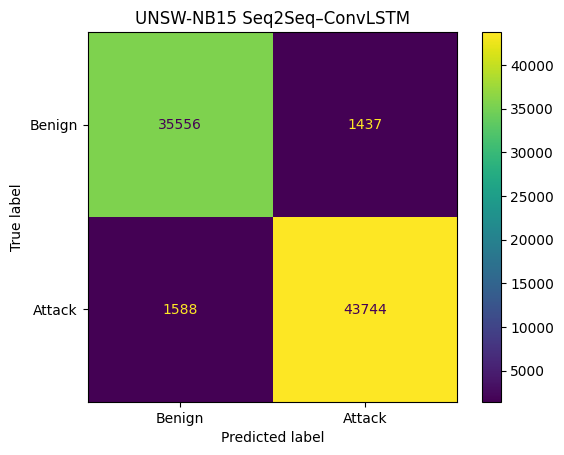

In [ ]:
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay
confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=test_matrix,
    display_labels=[
        "Benign",
        "Attack",
    ],
)

confusion_display.plot(
    values_format="d",
)

plt.title(
    "UNSW-NB15 Seq2Seq–ConvLSTM"
)

plt.show()

In [ ]:
model.save("/content/drive/MyDrive/Models_Table_7/seq2seq_convlstm_HARIHARAN.keras")